# 1 - İmport Data and Libraries

In [ ]:
%pip install xgboost lightgbm tensorflow catboost imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 137.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 130.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 169.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 155.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/

In [ ]:
# Gerekli kütüphanelerin import edilmesi.
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from imblearn.under_sampling import NearMiss
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [ ]:
import warnings
warnings.filterwarnings('ignore')

### Veri setini İmport Edelim

In [ ]:
# Veri setinin GitHub platformundan çekilip projeye dahil edilmesi.
url = "https://raw.githubusercontent.com/oztrkahmet/Heart-Attack-Prediction/refs/heads/main/Data/heart_attack_china.csv"

In [ ]:
# Verisetinin değişkene tanımlanması.
data = pd.read_csv(url)

# 2 - Exploratory Data Analysis - EDA

In [ ]:
# Veri setinin yapısını görmek için basit bir önbilgi alalım.
data.head()

,Patient_ID,Age,Gender,Smoking_Status,Hypertension,Diabetes,Obesity,Cholesterol_Level,Air_Pollution_Exposure,Physical_Activity,...,Hospital_Availability,TCM_Use,Employment_Status,Education_Level,Income_Level,Blood_Pressure,Chronic_Kidney_Disease,Previous_Heart_Attack,CVD_Risk_Score,Heart_Attack
0,1,55,Male,Non-Smoker,No,No,Yes,Normal,High,High,...,Low,Yes,Unemployed,Primary,Low,104,Yes,No,78,No
1,2,66,Female,Smoker,Yes,No,No,Low,Medium,High,...,High,No,Unemployed,Secondary,Middle,142,No,No,49,No
2,3,69,Female,Smoker,No,No,No,Low,Medium,High,...,Low,No,Unemployed,Primary,High,176,No,No,31,No
3,4,45,Female,Smoker,No,Yes,No,Normal,Medium,Low,...,Medium,Yes,Employed,Primary,Low,178,No,Yes,23,No
4,5,39,Female,Smoker,No,No,No,Normal,Medium,Medium,...,Low,No,Retired,Higher,Middle,146,Yes,No,79,No


In [ ]:
# Kategorik sütunların belirlenmesi
categorical_columns = data.select_dtypes(include=['object']).columns.tolist()
print("\nKategorik sütunlar:", categorical_columns)

# Benzersiz değerlerin sayısını kontrol edelim
for col in categorical_columns:
    print(f"\n{col} sütunu benzersiz değerleri:")
    print(data[col].value_counts())


Kategorik sütunlar: ['Gender', 'Smoking_Status', 'Hypertension', 'Diabetes', 'Obesity', 'Cholesterol_Level', 'Air_Pollution_Exposure', 'Physical_Activity', 'Diet_Score', 'Stress_Level', 'Alcohol_Consumption', 'Family_History_CVD', 'Healthcare_Access', 'Rural_or_Urban', 'Region', 'Province', 'Hospital_Availability', 'TCM_Use', 'Employment_Status', 'Education_Level', 'Income_Level', 'Chronic_Kidney_Disease', 'Previous_Heart_Attack', 'Heart_Attack']

Gender sütunu benzersiz değerleri:
Gender
Female    119948
Male      119318
Name: count, dtype: int64

Smoking_Status sütunu benzersiz değerleri:
Smoking_Status
Non-Smoker    119697
Smoker        119569
Name: count, dtype: int64

Hypertension sütunu benzersiz değerleri:
Hypertension
No     174557
Yes     64709
Name: count, dtype: int64

Diabetes sütunu benzersiz değerleri:
Diabetes
No     212794
Yes     26472
Name: count, dtype: int64

Obesity sütunu benzersiz değerleri:
Obesity
No     167521
Yes     71745
Name: count, dtype: int64

Choleste

In [ ]:
# Veri setinin içeriğini tüm sütunları dahil olmak üzere ayrıntılı görmek için.
pd.set_option('display.max_columns', None)

In [ ]:
# Veri setinin ayrıntılı istatistiklerini ve özelliklerini görme.
print(data.describe(include='all'))

           Patient_ID            Age  Gender Smoking_Status Hypertension  \
count   239266.000000  239266.000000  239266         239266       239266   
unique            NaN            NaN       2              2            2   
top               NaN            NaN  Female     Non-Smoker           No   
freq              NaN            NaN  119948         119697       174557   
mean    119633.500000      59.466284     NaN            NaN          NaN   
std      69070.289091      17.348308     NaN            NaN          NaN   
min          1.000000      30.000000     NaN            NaN          NaN   
25%      59817.250000      44.000000     NaN            NaN          NaN   
50%     119633.500000      59.000000     NaN            NaN          NaN   
75%     179449.750000      75.000000     NaN            NaN          NaN   
max     239266.000000      89.000000     NaN            NaN          NaN   

       Diabetes Obesity Cholesterol_Level Air_Pollution_Exposure  \
count    239266  23

In [ ]:
# Tekrar eden satırların kontrolü:
tekrarlananlar = data.duplicated(keep="first")

In [ ]:
# Eğer var ise tekrarlanan indislerin görsel olarak çıktısı:
data[tekrarlananlar]

,Patient_ID,Age,Gender,Smoking_Status,Hypertension,Diabetes,Obesity,Cholesterol_Level,Air_Pollution_Exposure,Physical_Activity,Diet_Score,Stress_Level,Alcohol_Consumption,Family_History_CVD,Healthcare_Access,Rural_or_Urban,Region,Province,Hospital_Availability,TCM_Use,Employment_Status,Education_Level,Income_Level,Blood_Pressure,Chronic_Kidney_Disease,Previous_Heart_Attack,CVD_Risk_Score,Heart_Attack


### Sütun İsimlendirme

In [ ]:
# Sütunların isimlerini değiştirelim:
yeni_isimler = {
    'Patient_ID': 'Hasta_ID',
    'Age': 'Yas',
    'Gender': 'Cinsiyet',
    'Smoking_Status': 'Sigara_Durumu',
    'Hypertension': 'Hipertansiyon',
    'Diabetes': 'Diyabet',
    'Obesity': 'Obezite',
    'Cholesterol_Level': 'Kolesterol_Seviyesi',
    'Air_Pollution_Exposure': 'Hava_Kirliligi_Maruziyeti',
    'Physical_Activity': 'Fiziksel_Aktivite',
    'Diet_Score': 'Diyet_Puani',
    'Stress_Level': 'Stres_Seviyesi',
    'Alcohol_Consumption': 'Alkol_Tuketimi',
    'Family_History_CVD': 'Aile_KVH_Gecmisi', # KVH: Kardiyovasküler Hastalık
    'Healthcare_Access': 'Saglik_Hizmetlerine_Erisim',
    'Rural_or_Urban': 'Kirsal_veya_Kentsel',
    'Region': 'Bolge',
    'Province': 'Eyalet',
    'Hospital_Availability': 'Hastane_Mevcudiyeti',
    'TCM_Use': 'GCT_Kullanimi', # GCT: Geleneksel Çin Tıbbı
    'Employment_Status': 'Istihdam_Durumu',
    'Education_Level': 'Egitim_Seviyesi',
    'Income_Level': 'Gelir_Seviyesi',
    'Blood_Pressure': 'Kan_Basinci',
    'Chronic_Kidney_Disease': 'Kronik_Bobrek_Hastaligi',
    'Previous_Heart_Attack': 'Onceki_Kalp_Krizi',
    'CVD_Risk_Score': 'KVH_Risk_Puani',
    'Heart_Attack': 'Kalp_Krizi' # Hedef değişken
}
data = data.rename(columns=yeni_isimler)

In [ ]:
print("DataFrame'in Yeni Sütun İsimleri:")
print(data.columns.tolist())

DataFrame'in Yeni Sütun İsimleri:
['Hasta_ID', 'Yas', 'Cinsiyet', 'Sigara_Durumu', 'Hipertansiyon', 'Diyabet', 'Obezite', 'Kolesterol_Seviyesi', 'Hava_Kirliligi_Maruziyeti', 'Fiziksel_Aktivite', 'Diyet_Puani', 'Stres_Seviyesi', 'Alkol_Tuketimi', 'Aile_KVH_Gecmisi', 'Saglik_Hizmetlerine_Erisim', 'Kirsal_veya_Kentsel', 'Bolge', 'Eyalet', 'Hastane_Mevcudiyeti', 'GCT_Kullanimi', 'Istihdam_Durumu', 'Egitim_Seviyesi', 'Gelir_Seviyesi', 'Kan_Basinci', 'Kronik_Bobrek_Hastaligi', 'Onceki_Kalp_Krizi', 'KVH_Risk_Puani', 'Kalp_Krizi']


In [ ]:
# Veri setimizdeki Patient_ID sütunu işimize yaramayacağından ve gereksiz bir boyut oluşturacağından verisetinden çıkarıyoruz:
data = data.drop('Hasta_ID',axis=1)

### Sütunlar Hakkında Genel Bilgiler

In [ ]:
# Veri seti sütunları hakkında bilgiler edinme.
print("\n Veri Seti Bilgileri (Sütunlar, Veri Tipleri, Eksik Olmayan Değerler):")
data.info()


 Veri Seti Bilgileri (Sütunlar, Veri Tipleri, Eksik Olmayan Değerler):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239266 entries, 0 to 239265
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   Yas                         239266 non-null  int64 
 1   Cinsiyet                    239266 non-null  object
 2   Sigara_Durumu               239266 non-null  object
 3   Hipertansiyon               239266 non-null  object
 4   Diyabet                     239266 non-null  object
 5   Obezite                     239266 non-null  object
 6   Kolesterol_Seviyesi         239266 non-null  object
 7   Hava_Kirliligi_Maruziyeti   239266 non-null  object
 8   Fiziksel_Aktivite           239266 non-null  object
 9   Diyet_Puani                 239266 non-null  object
 10  Stres_Seviyesi              239266 non-null  object
 11  Alkol_Tuketimi              239266 non-null  object
 12  Aile_KVH_Gecmi

In [ ]:
# Sayısal sütunların istatistiksel özellikleri.
print("\n Sayısal Sütunlar İçin İstatistiksel Özet:")
print(data.describe().T) # .T ile çıktının transpozesini alarak daha iyi görünmesini sağladık.


 Sayısal Sütunlar İçin İstatistiksel Özet:
                   count        mean        std   min    25%    50%    75%  \
Yas             239266.0   59.466284  17.348308  30.0   44.0   59.0   75.0   
Kan_Basinci     239266.0  134.513378  25.991827  90.0  112.0  135.0  157.0   
KVH_Risk_Puani  239266.0   54.485581  25.987743  10.0   32.0   54.0   77.0   

                  max  
Yas              89.0  
Kan_Basinci     179.0  
KVH_Risk_Puani   99.0  


In [ ]:
# Kategorik sütunların istatistiksel özellikleri.
print("\n Kategorik Sütunlar İçin İstatistiksel Özet:")
print(data.describe(include='object').T)


 Kategorik Sütunlar İçin İstatistiksel Özet:
                             count unique         top    freq
Cinsiyet                    239266      2      Female  119948
Sigara_Durumu               239266      2  Non-Smoker  119697
Hipertansiyon               239266      2          No  174557
Diyabet                     239266      2          No  212794
Obezite                     239266      2          No  167521
Kolesterol_Seviyesi         239266      3      Normal   80091
Hava_Kirliligi_Maruziyeti   239266      3      Medium  119593
Fiziksel_Aktivite           239266      3         Low   80086
Diyet_Puani                 239266      3    Moderate   79954
Stres_Seviyesi              239266      3         Low   80120
Alkol_Tuketimi              239266      2          No  167156
Aile_KVH_Gecmisi            239266      2          No  179740
Saglik_Hizmetlerine_Erisim  239266      3        Poor   79912
Kirsal_veya_Kentsel         239266      2       Rural  143507
Bolge                   

In [ ]:
# Her sütundaki benzersiz değer sayısını inceleyelim.
print("\n Her Sütundaki Benzersiz Değer Sayısı:")
print(data.nunique())


 Her Sütundaki Benzersiz Değer Sayısı:
Yas                           60
Cinsiyet                       2
Sigara_Durumu                  2
Hipertansiyon                  2
Diyabet                        2
Obezite                        2
Kolesterol_Seviyesi            3
Hava_Kirliligi_Maruziyeti      3
Fiziksel_Aktivite              3
Diyet_Puani                    3
Stres_Seviyesi                 3
Alkol_Tuketimi                 2
Aile_KVH_Gecmisi               2
Saglik_Hizmetlerine_Erisim     3
Kirsal_veya_Kentsel            2
Bolge                          5
Eyalet                         8
Hastane_Mevcudiyeti            3
GCT_Kullanimi                  2
Istihdam_Durumu                3
Egitim_Seviyesi                3
Gelir_Seviyesi                 3
Kan_Basinci                   90
Kronik_Bobrek_Hastaligi        2
Onceki_Kalp_Krizi              2
KVH_Risk_Puani                90
Kalp_Krizi                     2
dtype: int64


### Eksik Veri Kontrolü

In [ ]:
# Tüm veri setindeki eksik veri olan yerleri tespit edelim.
print(data.isnull().sum())

Yas                               0
Cinsiyet                          0
Sigara_Durumu                     0
Hipertansiyon                     0
Diyabet                           0
Obezite                           0
Kolesterol_Seviyesi               0
Hava_Kirliligi_Maruziyeti         0
Fiziksel_Aktivite                 0
Diyet_Puani                       0
Stres_Seviyesi                    0
Alkol_Tuketimi                    0
Aile_KVH_Gecmisi                  0
Saglik_Hizmetlerine_Erisim        0
Kirsal_veya_Kentsel               0
Bolge                             0
Eyalet                            0
Hastane_Mevcudiyeti               0
GCT_Kullanimi                     0
Istihdam_Durumu                   0
Egitim_Seviyesi               59617
Gelir_Seviyesi                    0
Kan_Basinci                       0
Kronik_Bobrek_Hastaligi           0
Onceki_Kalp_Krizi                 0
KVH_Risk_Puani                    0
Kalp_Krizi                        0
dtype: int64


In [ ]:
missing_values = data.isnull().sum()

In [ ]:
missing_percentage = (missing_values / len(data)) * 100

In [ ]:
missing_info = pd.DataFrame({'Eksik Değer Sayısı': missing_values, 'Yüzde (%)': missing_percentage})

In [ ]:
missing_info = missing_info[missing_info['Eksik Değer Sayısı'] > 0].sort_values(by='Yüzde (%)', ascending=False)

In [ ]:
print("\n Eksik Verilerin Analizi:")
if missing_info.empty:
    print("Veri setinde eksik değer bulunmamakta.")
else:
    print(missing_info)


 Eksik Verilerin Analizi:
                 Eksik Değer Sayısı  Yüzde (%)
Egitim_Seviyesi               59617   24.91662


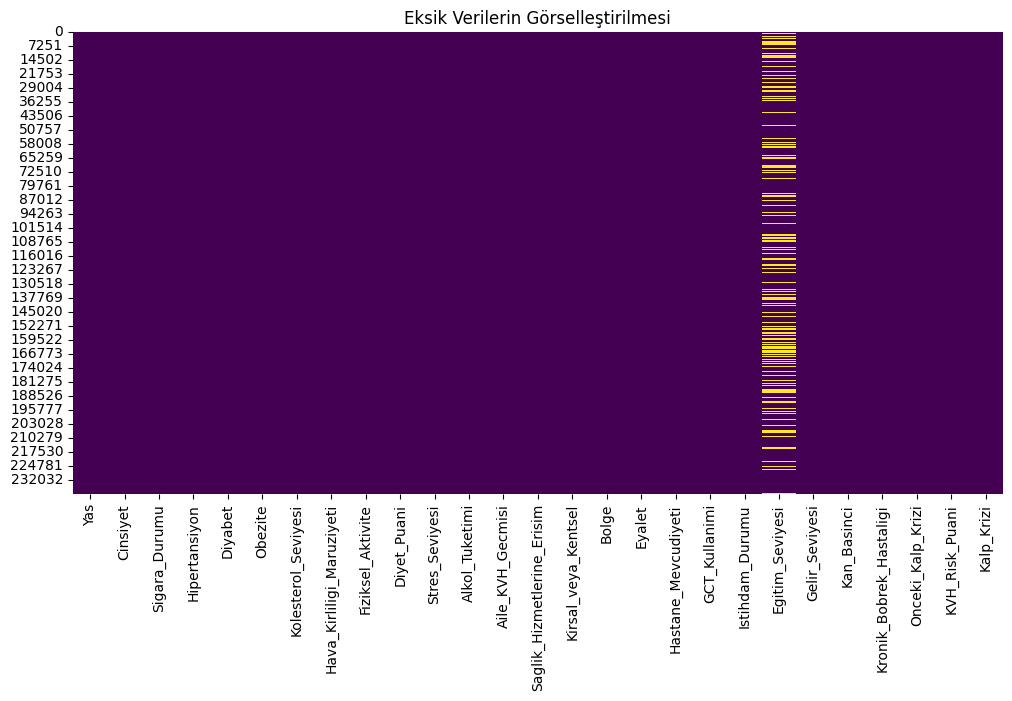

In [ ]:
# Eksik verileri grafik üzerinde görselleştirelim.
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Eksik Verilerin Görselleştirilmesi')
plt.show()

In [ ]:
# Eksik veri bulunan sütundaki değerleri sayıları ile birlikte görelim.
print(data["Egitim_Seviyesi"].value_counts(dropna=False))

Egitim_Seviyesi
Higher       59942
Primary      59901
Secondary    59806
NaN          59617
Name: count, dtype: int64


In [ ]:
# Eksik veri bulunan sütundaki değerleri kategori olarak görelim.
print(data["Egitim_Seviyesi"].unique())

['Primary' 'Secondary' 'Higher' nan]


In [ ]:
# Bu kısımda veri seti incelendiğinde "none" değerinin aslında eksik veri değil de okumamış kişi anlamında olduğu anlaşılmıştır.
# Bu sebeple modellerin "none" değerini eksik veri görme sorunundan kurtarmak için bu değeri "uneducated" olark değiştirdik
# ve veri setindeki değerleri bu yeni değerlere güncelledik.
data["Egitim_Seviyesi"] = data["Egitim_Seviyesi"].fillna("Uneducated")

In [ ]:
# veri güncellemesi sonrası kategorileri tekrar görüntüleyelim.
print(data["Egitim_Seviyesi"].unique())

['Primary' 'Secondary' 'Higher' 'Uneducated']


In [ ]:
# verinin güncellenmesi sonrası eksik verinin varlığını tekrar kontrol edelim.
print(data.isnull().sum())

Yas                           0
Cinsiyet                      0
Sigara_Durumu                 0
Hipertansiyon                 0
Diyabet                       0
Obezite                       0
Kolesterol_Seviyesi           0
Hava_Kirliligi_Maruziyeti     0
Fiziksel_Aktivite             0
Diyet_Puani                   0
Stres_Seviyesi                0
Alkol_Tuketimi                0
Aile_KVH_Gecmisi              0
Saglik_Hizmetlerine_Erisim    0
Kirsal_veya_Kentsel           0
Bolge                         0
Eyalet                        0
Hastane_Mevcudiyeti           0
GCT_Kullanimi                 0
Istihdam_Durumu               0
Egitim_Seviyesi               0
Gelir_Seviyesi                0
Kan_Basinci                   0
Kronik_Bobrek_Hastaligi       0
Onceki_Kalp_Krizi             0
KVH_Risk_Puani                0
Kalp_Krizi                    0
dtype: int64


### Aykırı Değer Kontrolü

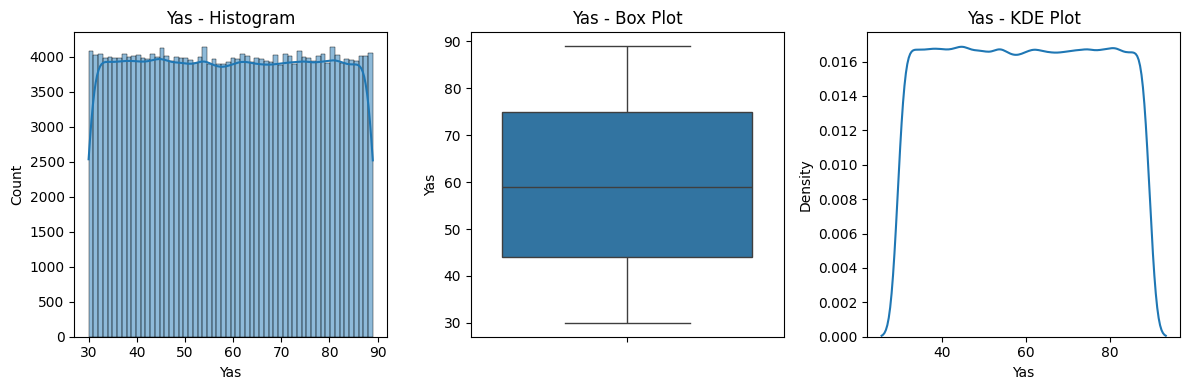


Yas İstatistikleri:
count    239266.000000
mean         59.466284
std          17.348308
min          30.000000
25%          44.000000
50%          59.000000
75%          75.000000
max          89.000000
Name: Yas, dtype: float64


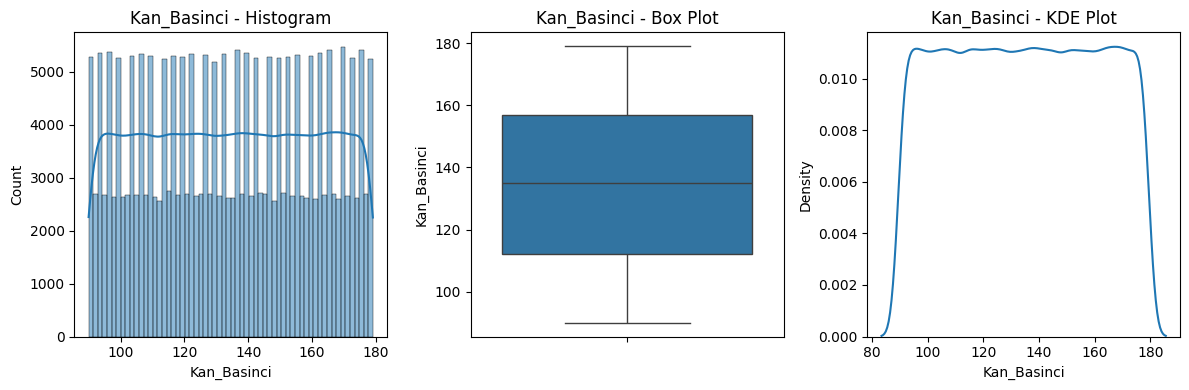


Kan_Basinci İstatistikleri:
count    239266.000000
mean        134.513378
std          25.991827
min          90.000000
25%         112.000000
50%         135.000000
75%         157.000000
max         179.000000
Name: Kan_Basinci, dtype: float64


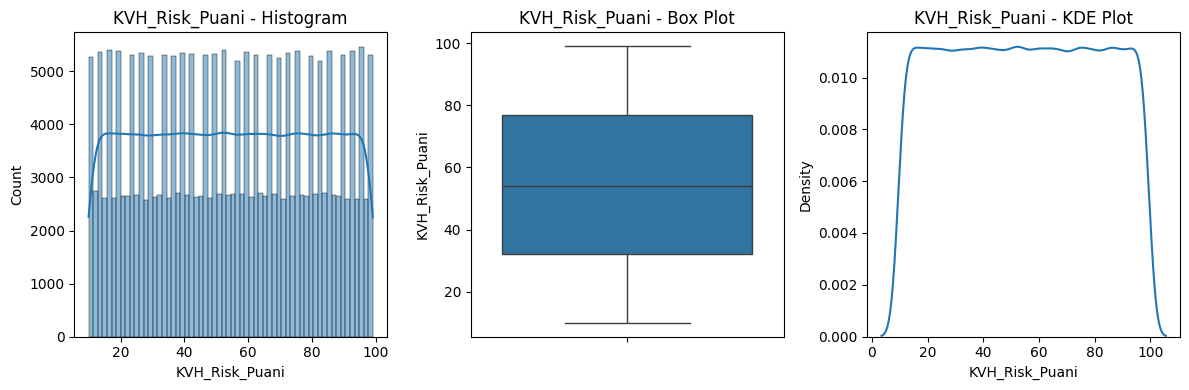


KVH_Risk_Puani İstatistikleri:
count    239266.000000
mean         54.485581
std          25.987743
min          10.000000
25%          32.000000
50%          54.000000
75%          77.000000
max          99.000000
Name: KVH_Risk_Puani, dtype: float64


In [ ]:
# Sayısal değerlerde aykırı değerlerin olup olmadığını ve verilerin genel dağılımını görmek için yoğunluk, kutu ve histogram grafiklerinden yararlandık.
numerical_cols = ['Yas', 'Kan_Basinci', 'KVH_Risk_Puani']

for col in numerical_cols:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'{col} - Histogram')

    plt.subplot(1, 3, 2)
    sns.boxplot(y=data[col])
    plt.title(f'{col} - Box Plot')

    plt.subplot(1, 3, 3)
    sns.kdeplot(data[col])
    plt.title(f'{col} - KDE Plot')

    plt.tight_layout()
    plt.show()

    print(f"\n{col} İstatistikleri:")
    print(data[col].describe())

### Hedef ve diğer niteliklerin Görselleştirilmesi

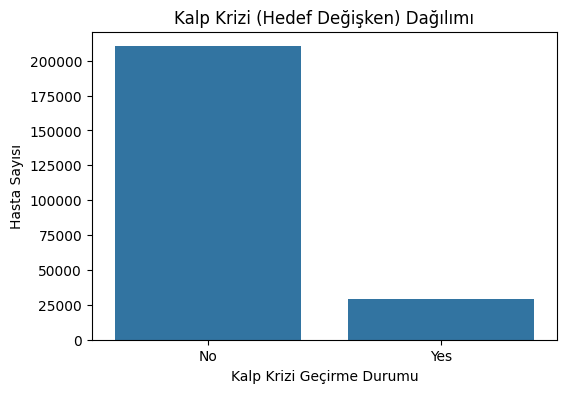

Kalp Krizi Yüzdesel Sınıf Dağılımı:
Kalp_Krizi
No     87.849924
Yes    12.150076
Name: proportion, dtype: float64


In [ ]:
# Hedef değişkenin dağılımını grafiksel olarak görüntüleyelim.
plt.figure(figsize=(6, 4))
sns.countplot(x='Kalp_Krizi', data=data)
plt.title('Kalp Krizi (Hedef Değişken) Dağılımı')
plt.xlabel('Kalp Krizi Geçirme Durumu')
plt.ylabel('Hasta Sayısı')
plt.show()

# Oranları da yazdırabilirsin
print("Kalp Krizi Yüzdesel Sınıf Dağılımı:")
print(data['Kalp_Krizi'].value_counts(normalize=True) * 100)

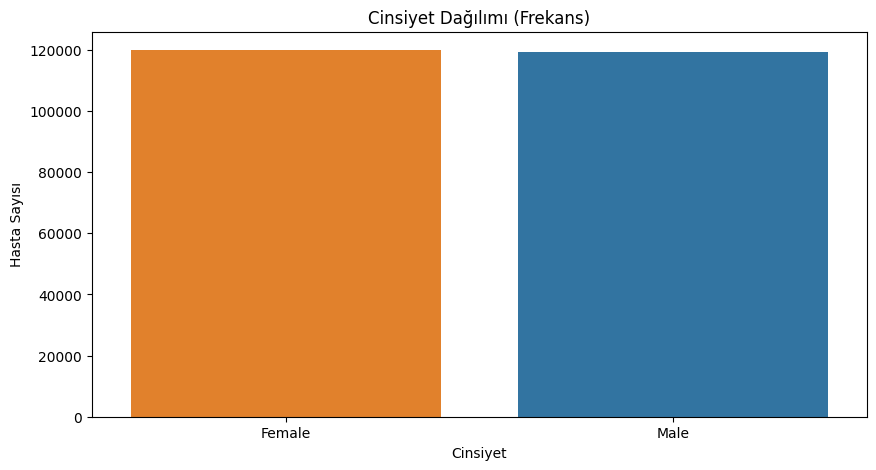


Cinsiyet Değer Sayıları:
Cinsiyet
Female    119948
Male      119318
Name: count, dtype: int64
------------------------------


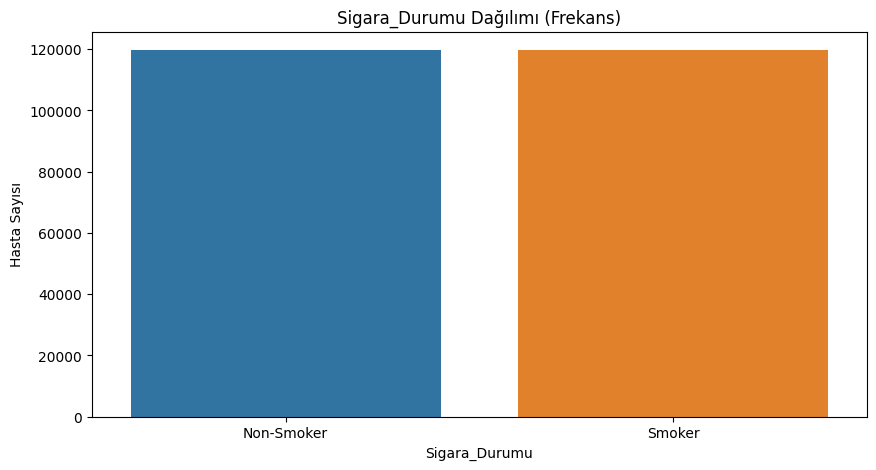


Sigara_Durumu Değer Sayıları:
Sigara_Durumu
Non-Smoker    119697
Smoker        119569
Name: count, dtype: int64
------------------------------


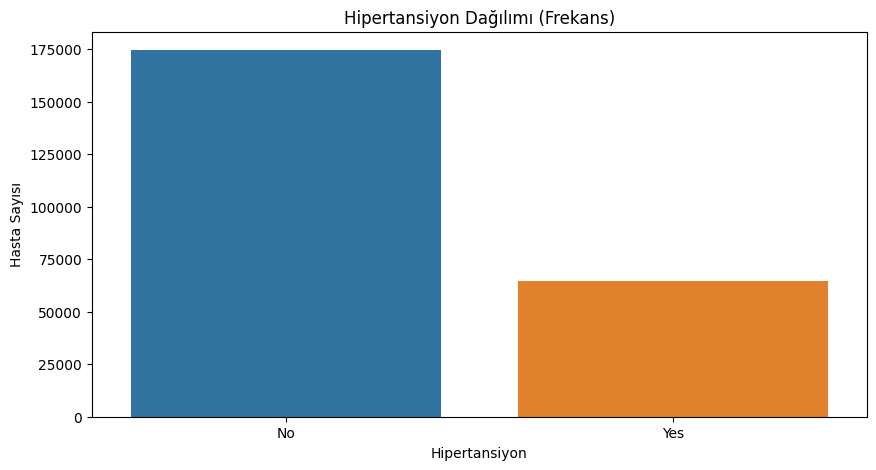


Hipertansiyon Değer Sayıları:
Hipertansiyon
No     174557
Yes     64709
Name: count, dtype: int64
------------------------------


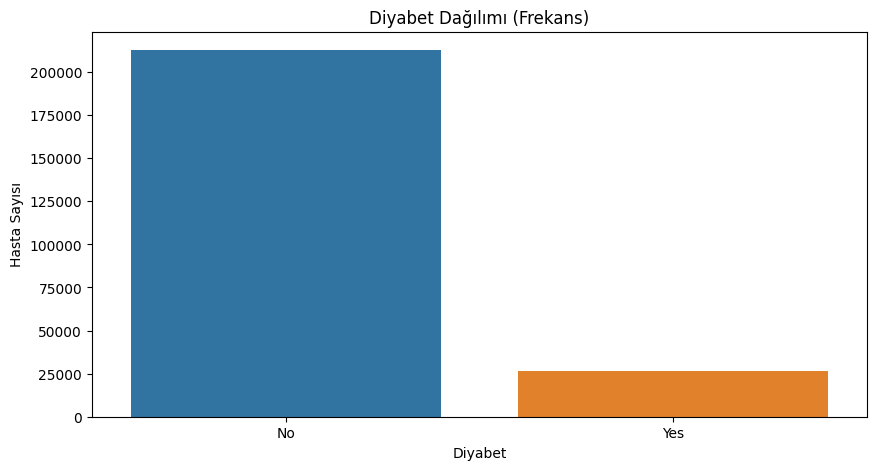


Diyabet Değer Sayıları:
Diyabet
No     212794
Yes     26472
Name: count, dtype: int64
------------------------------


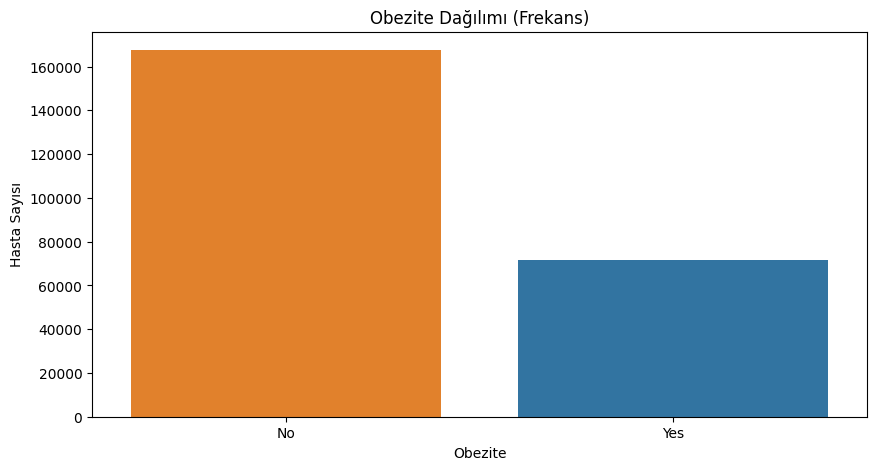


Obezite Değer Sayıları:
Obezite
No     167521
Yes     71745
Name: count, dtype: int64
------------------------------


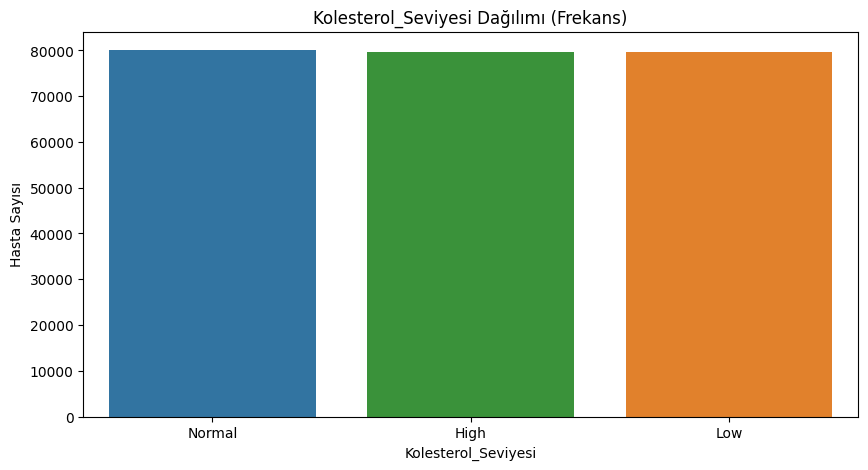


Kolesterol_Seviyesi Değer Sayıları:
Kolesterol_Seviyesi
Normal    80091
High      79620
Low       79555
Name: count, dtype: int64
------------------------------


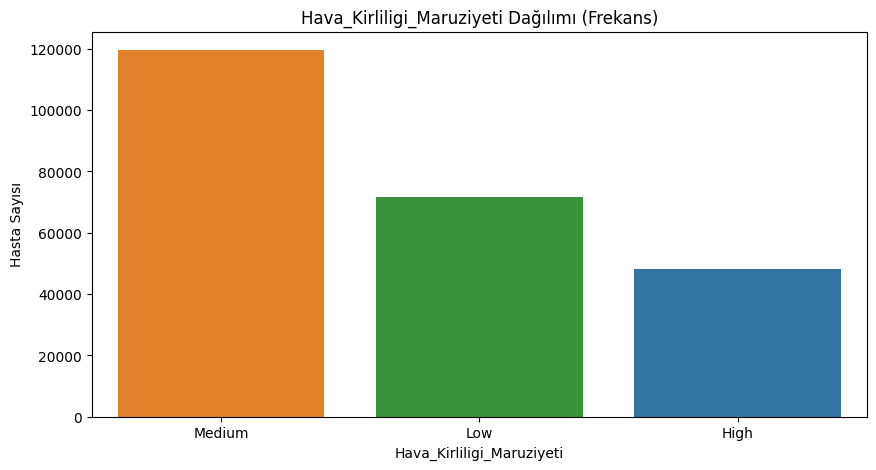


Hava_Kirliligi_Maruziyeti Değer Sayıları:
Hava_Kirliligi_Maruziyeti
Medium    119593
Low        71654
High       48019
Name: count, dtype: int64
------------------------------


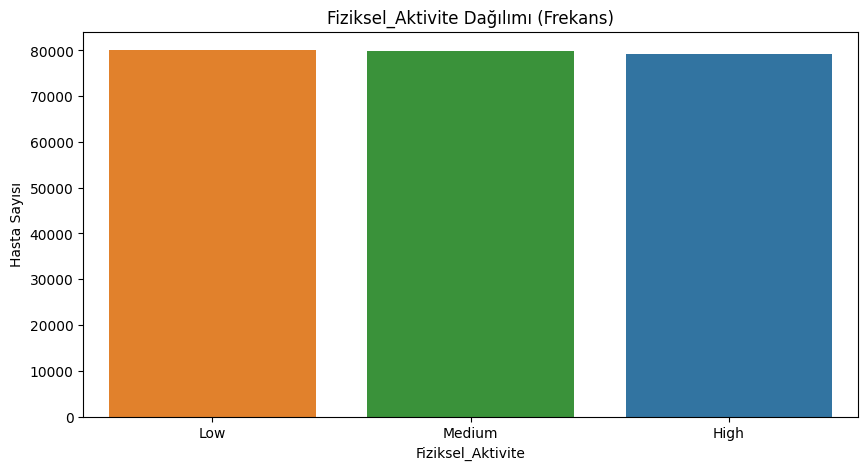


Fiziksel_Aktivite Değer Sayıları:
Fiziksel_Aktivite
Low       80086
Medium    79930
High      79250
Name: count, dtype: int64
------------------------------


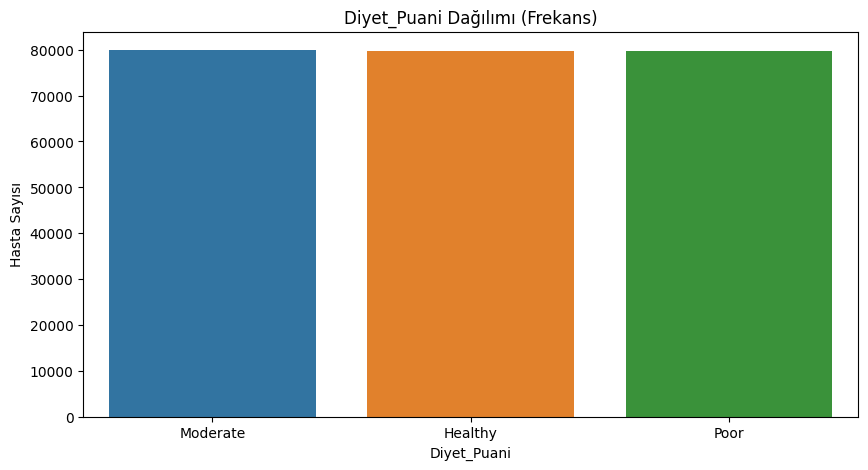


Diyet_Puani Değer Sayıları:
Diyet_Puani
Moderate    79954
Healthy     79656
Poor        79656
Name: count, dtype: int64
------------------------------


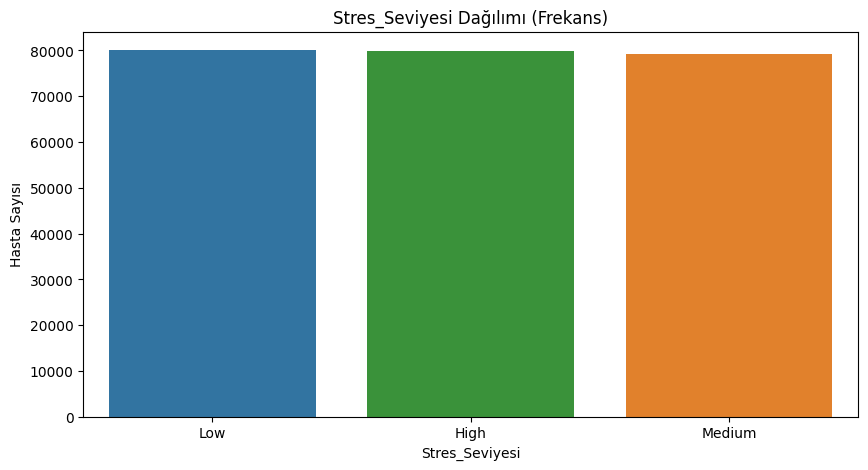


Stres_Seviyesi Değer Sayıları:
Stres_Seviyesi
Low       80120
High      79857
Medium    79289
Name: count, dtype: int64
------------------------------


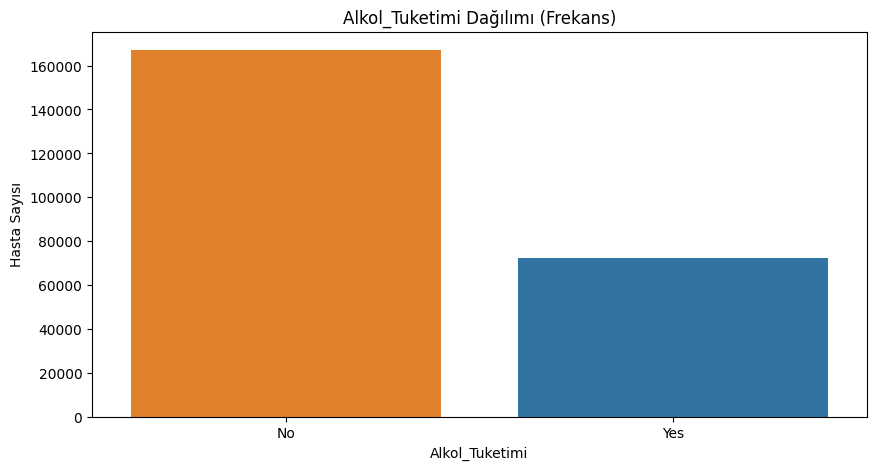


Alkol_Tuketimi Değer Sayıları:
Alkol_Tuketimi
No     167156
Yes     72110
Name: count, dtype: int64
------------------------------


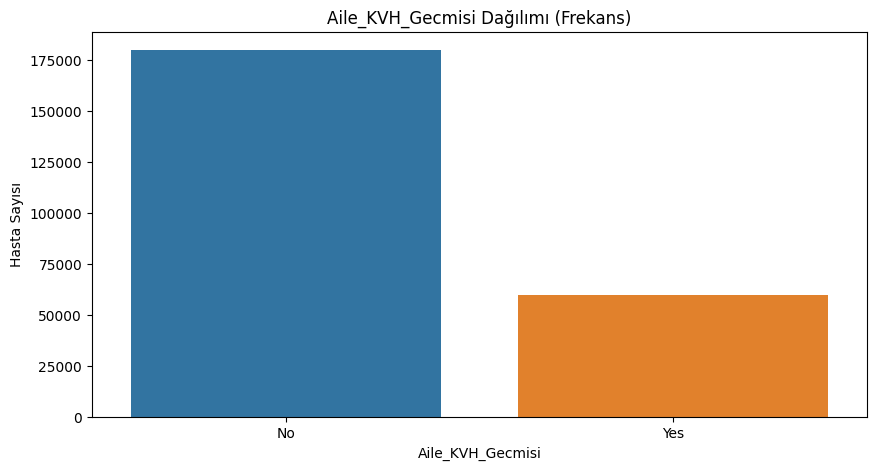


Aile_KVH_Gecmisi Değer Sayıları:
Aile_KVH_Gecmisi
No     179740
Yes     59526
Name: count, dtype: int64
------------------------------


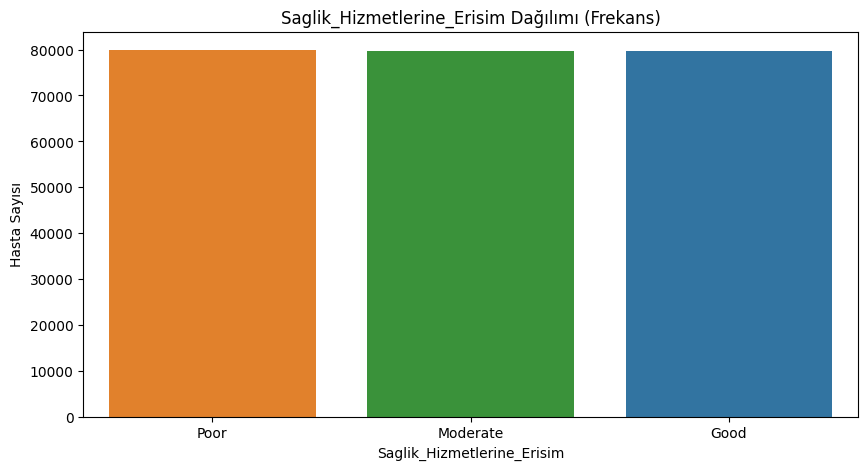


Saglik_Hizmetlerine_Erisim Değer Sayıları:
Saglik_Hizmetlerine_Erisim
Poor        79912
Moderate    79711
Good        79643
Name: count, dtype: int64
------------------------------


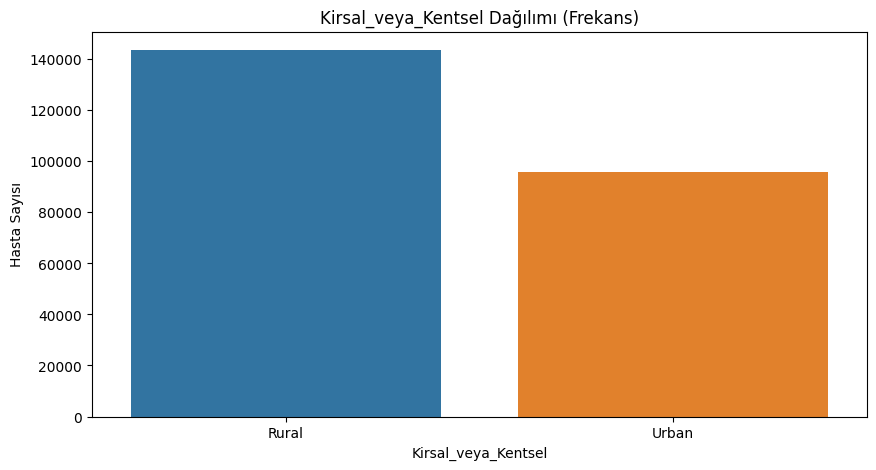


Kirsal_veya_Kentsel Değer Sayıları:
Kirsal_veya_Kentsel
Rural    143507
Urban     95759
Name: count, dtype: int64
------------------------------


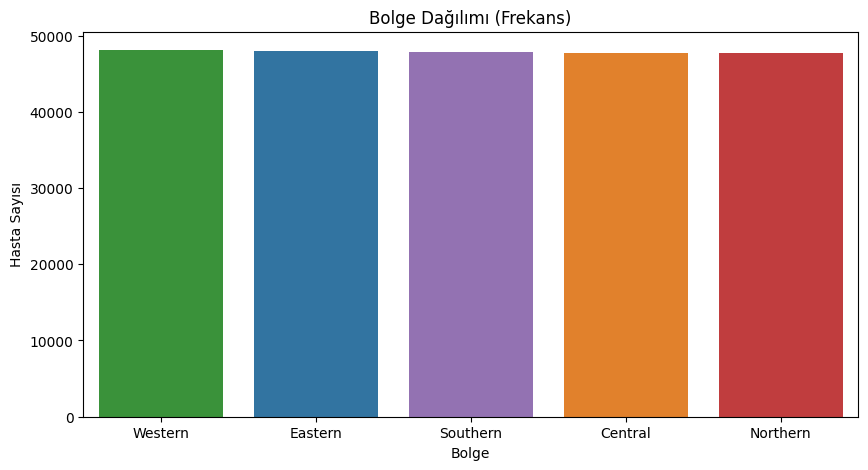


Bolge Değer Sayıları:
Bolge
Western     48100
Eastern     47959
Southern    47826
Central     47694
Northern    47687
Name: count, dtype: int64
------------------------------


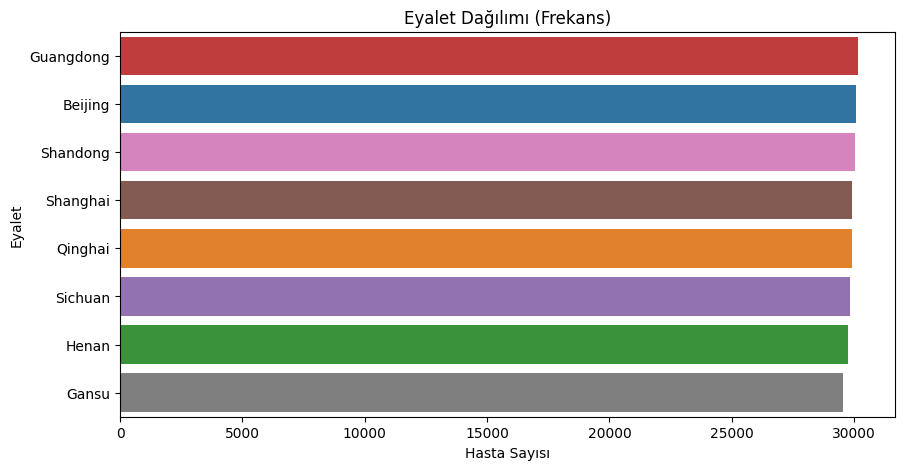


Eyalet Değer Sayıları:
Eyalet
Guangdong    30162
Beijing      30064
Shandong     30025
Shanghai     29932
Qinghai      29917
Sichuan      29850
Henan        29767
Gansu        29549
Name: count, dtype: int64
------------------------------


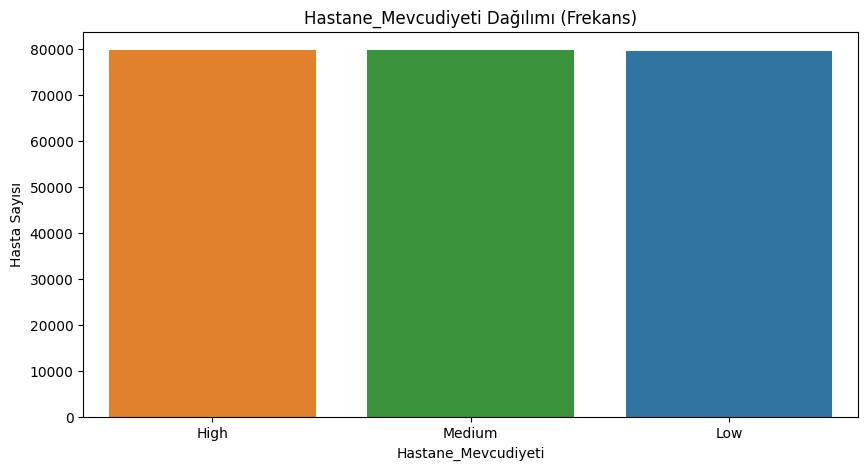


Hastane_Mevcudiyeti Değer Sayıları:
Hastane_Mevcudiyeti
High      79848
Medium    79829
Low       79589
Name: count, dtype: int64
------------------------------


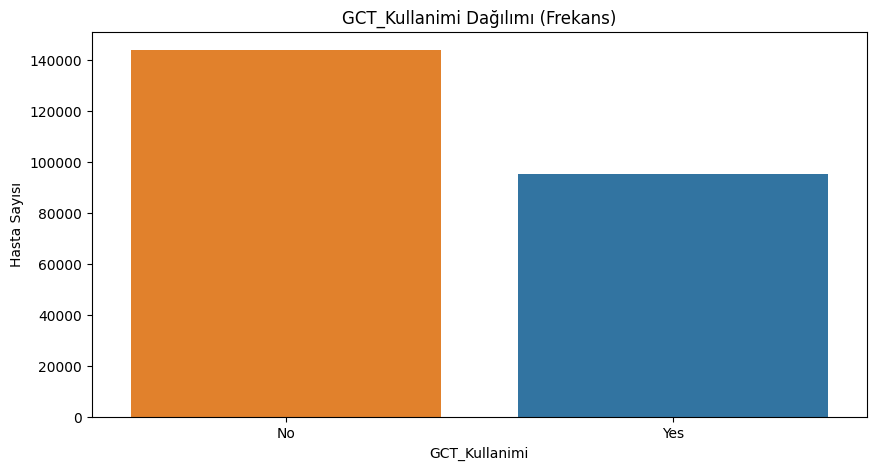


GCT_Kullanimi Değer Sayıları:
GCT_Kullanimi
No     143949
Yes     95317
Name: count, dtype: int64
------------------------------


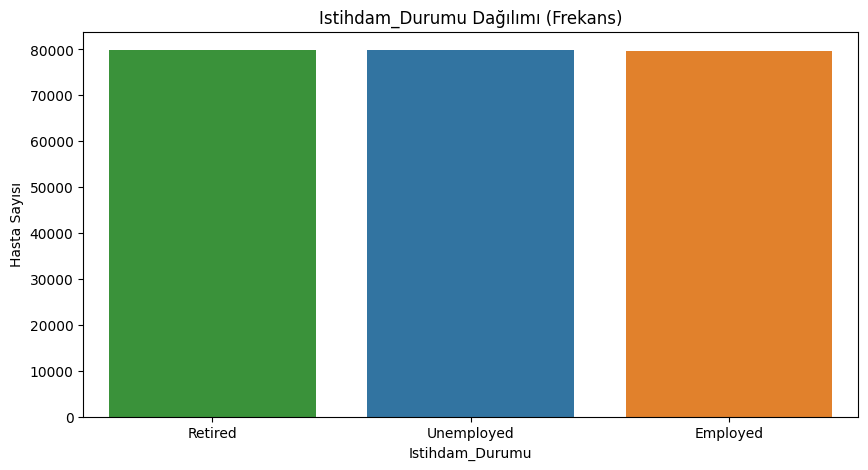


Istihdam_Durumu Değer Sayıları:
Istihdam_Durumu
Retired       79872
Unemployed    79756
Employed      79638
Name: count, dtype: int64
------------------------------


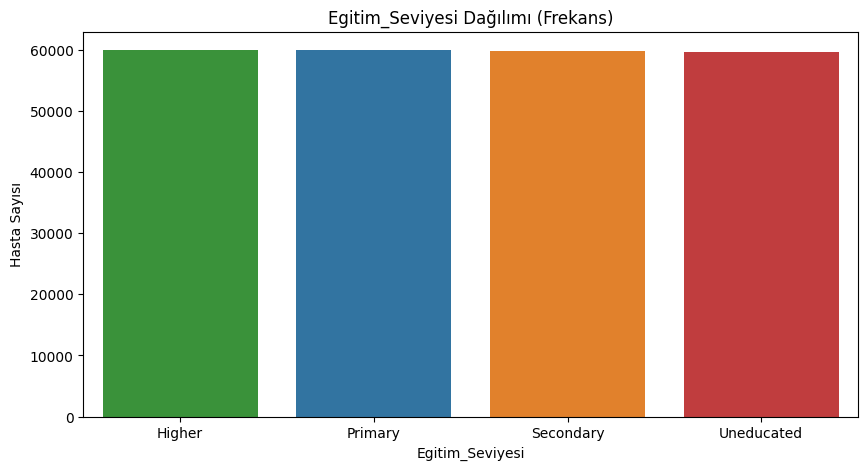


Egitim_Seviyesi Değer Sayıları:
Egitim_Seviyesi
Higher        59942
Primary       59901
Secondary     59806
Uneducated    59617
Name: count, dtype: int64
------------------------------


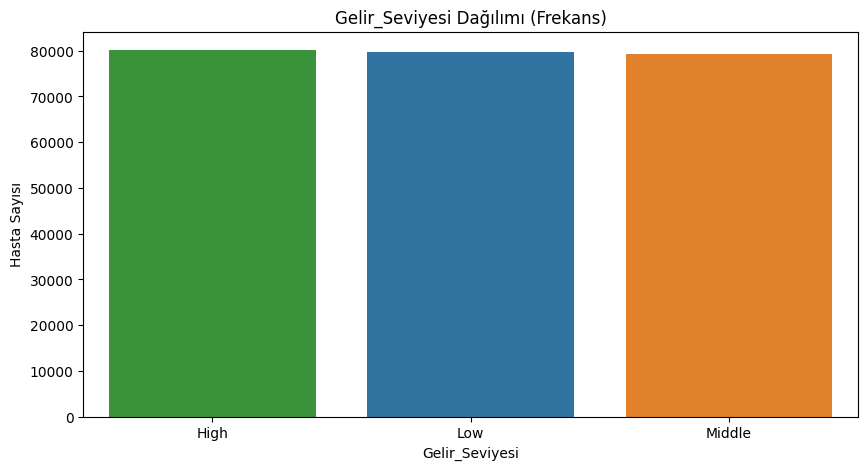


Gelir_Seviyesi Değer Sayıları:
Gelir_Seviyesi
High      80149
Low       79797
Middle    79320
Name: count, dtype: int64
------------------------------


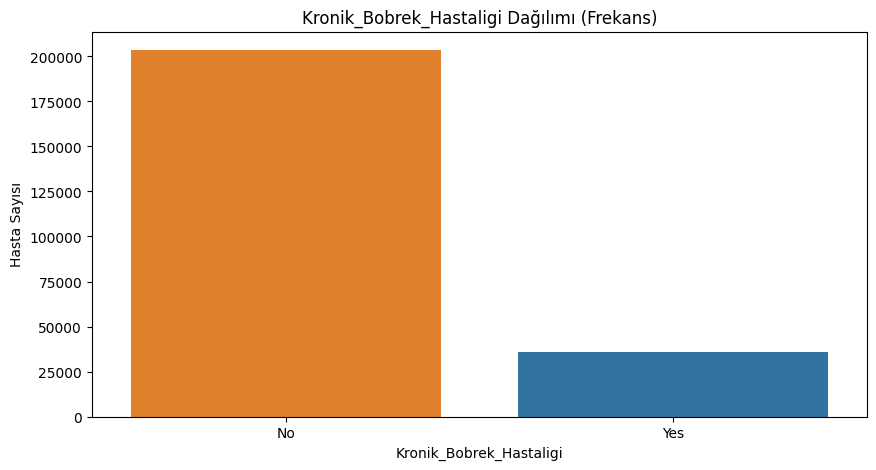


Kronik_Bobrek_Hastaligi Değer Sayıları:
Kronik_Bobrek_Hastaligi
No     203597
Yes     35669
Name: count, dtype: int64
------------------------------


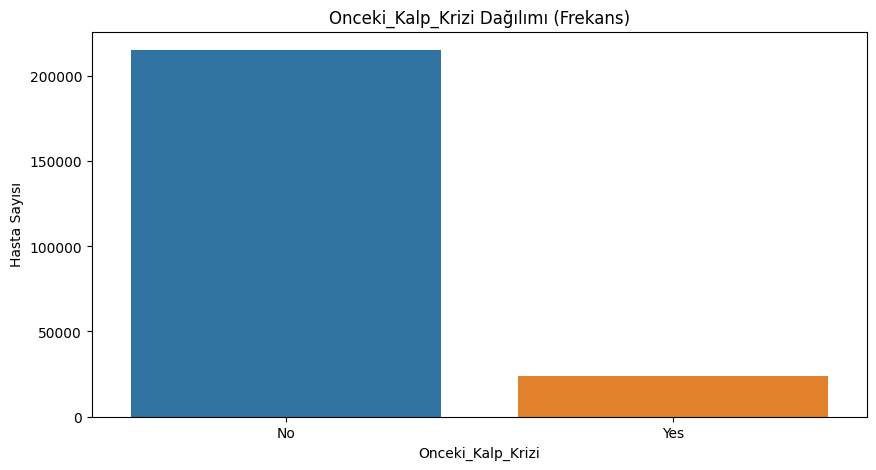


Onceki_Kalp_Krizi Değer Sayıları:
Onceki_Kalp_Krizi
No     215306
Yes     23960
Name: count, dtype: int64
------------------------------


In [ ]:
# Object türündeki sütunlarda bulunan kategorilerin baskınlık durumlarını görselleştirerek veriyi inceledik.
# Hedef değişkeni almadık.
categorical_cols = data.select_dtypes(include='object').columns.tolist()
# Eğer hedef değişken object ise görselleştirmeden çıkarılsın olarak belirledik.
if 'Kalp_Krizi' in categorical_cols: categorical_cols.remove('Kalp_Krizi')

# Kullanılacak renk paletini seçelim
palette_choice = 'tab10'

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    # kategori sayısı çok fazlaysa y ekseninde gösterilmesi için
    if data[col].nunique() > 5:
        sns.countplot(y=col, data=data, order = data[col].value_counts().index, palette=palette_choice, hue=col, legend=False)
        plt.title(f'{col} Dağılımı (Frekans)')
        plt.xlabel('Hasta Sayısı')
        plt.ylabel(col)
    else:
        sns.countplot(x=col, data=data, order = data[col].value_counts().index, palette=palette_choice, hue=col, legend=False)
        plt.title(f'{col} Dağılımı (Frekans)')
        plt.xlabel(col)
        plt.ylabel('Hasta Sayısı')
    plt.show()
    print(f"\n{col} Değer Sayıları:")
    print(data[col].value_counts())
    print("-" * 30)

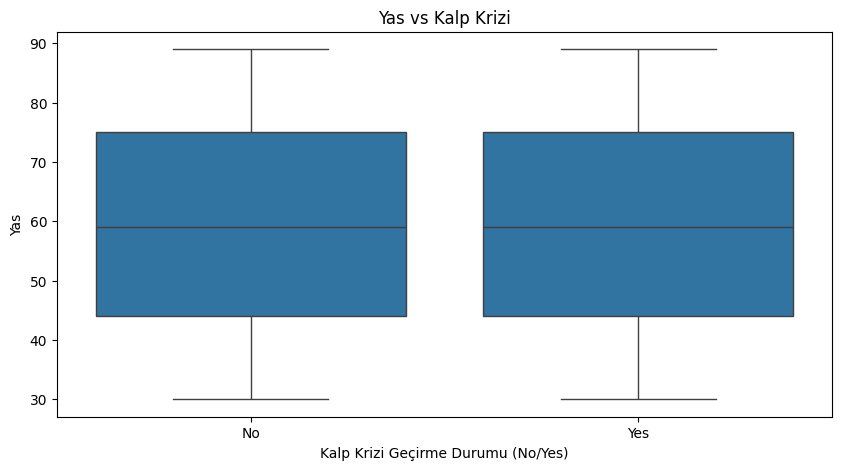

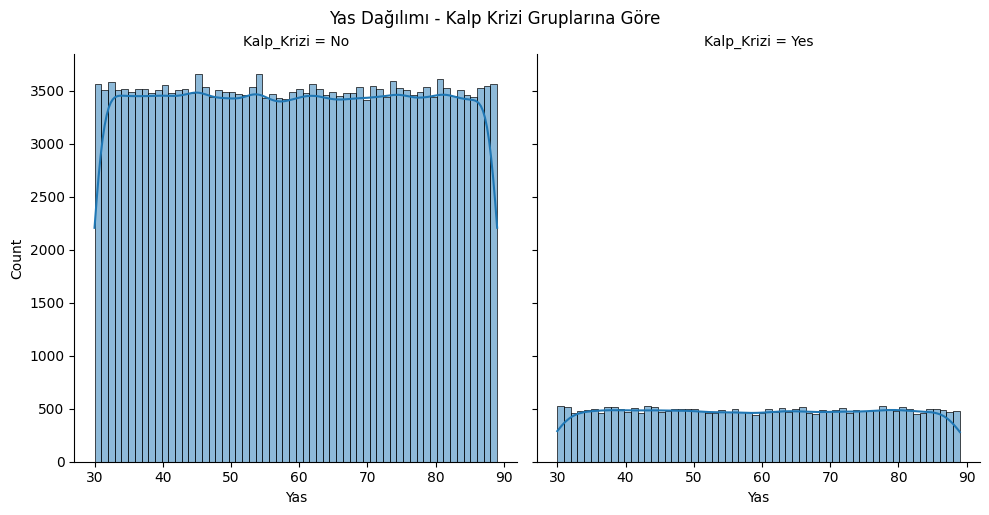

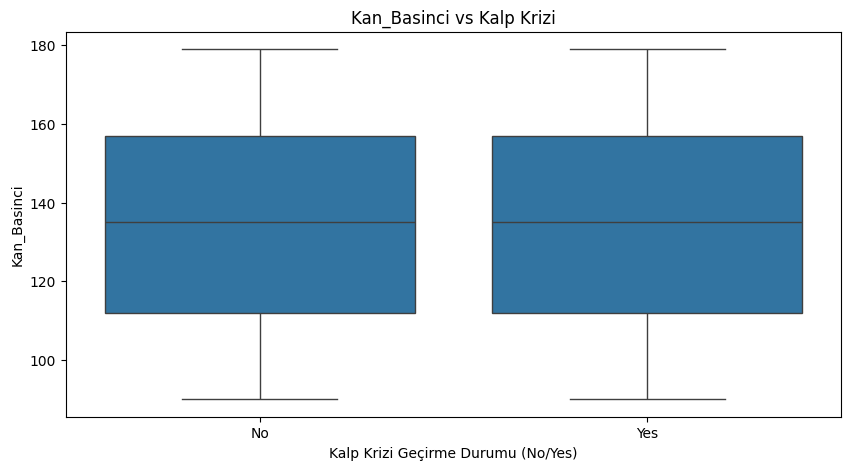

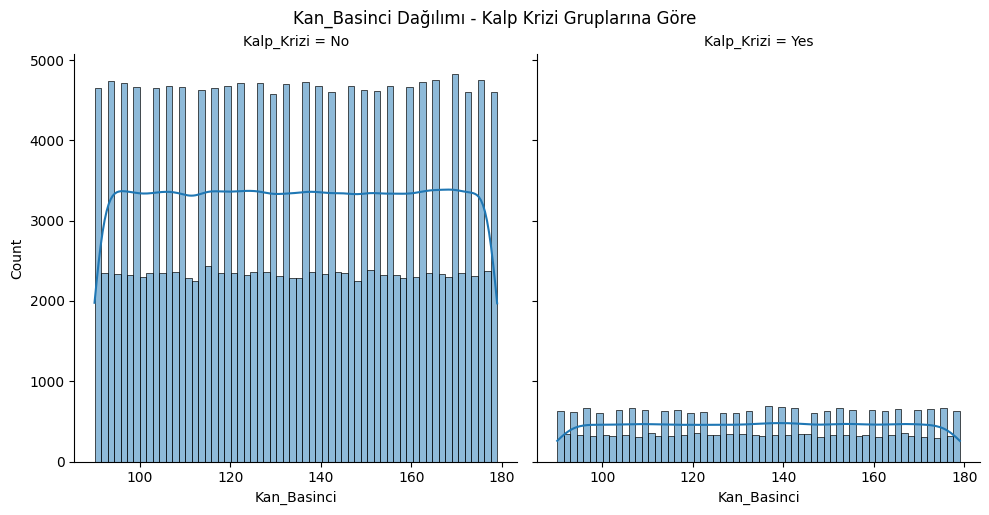

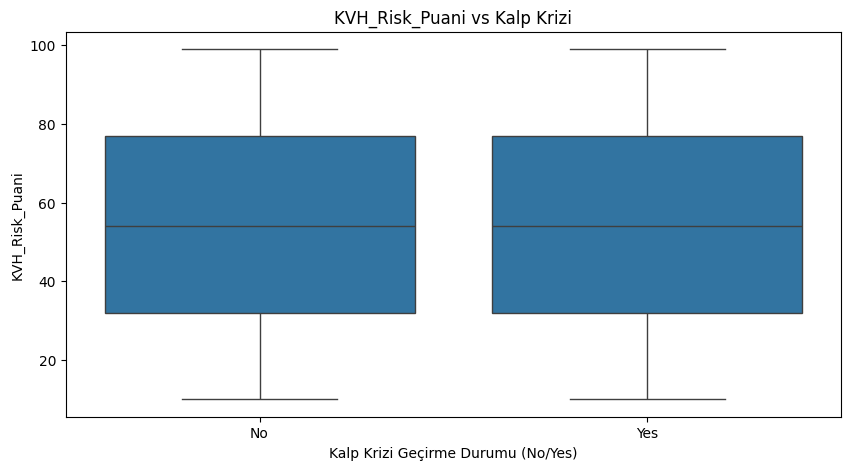

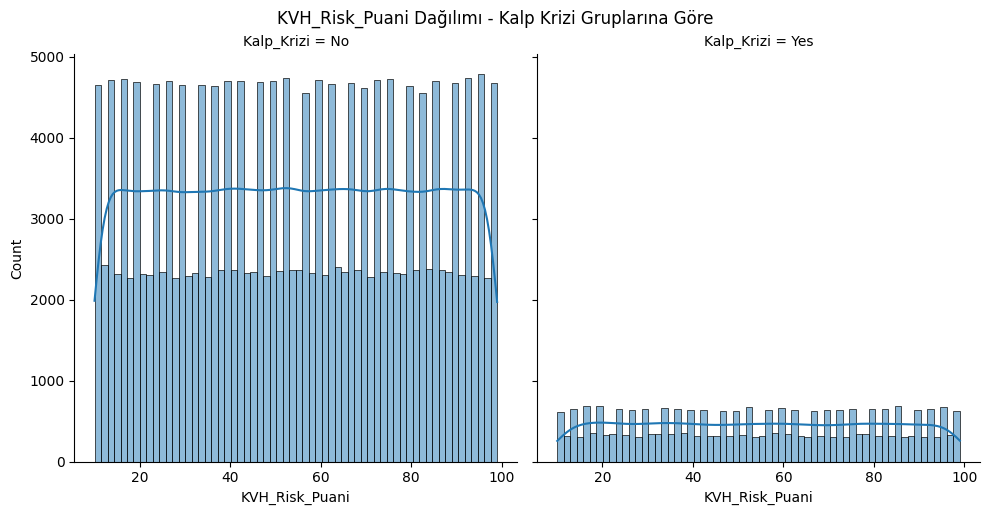

In [ ]:
# Sayısal verilerin hedef değişken ile karşılaştırılması ve kalp krizi geçiren ve geçirmeyen gruplar arasında nasıl farklılaştığını inceleyelim.
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Kalp_Krizi', y=col, data=data)
    plt.title(f'{col} vs Kalp Krizi')
    plt.xlabel('Kalp Krizi Geçirme Durumu (No/Yes)')
    plt.ylabel(col)
    plt.show()

    # Histogramları yan yana görelim.
    sns.displot(data=data, x=col, col='Kalp_Krizi', kde=True)
    plt.suptitle(f'{col} Dağılımı - Kalp Krizi Gruplarına Göre', y=1.02)
    plt.show()

<Figure size 1000x600 with 0 Axes>

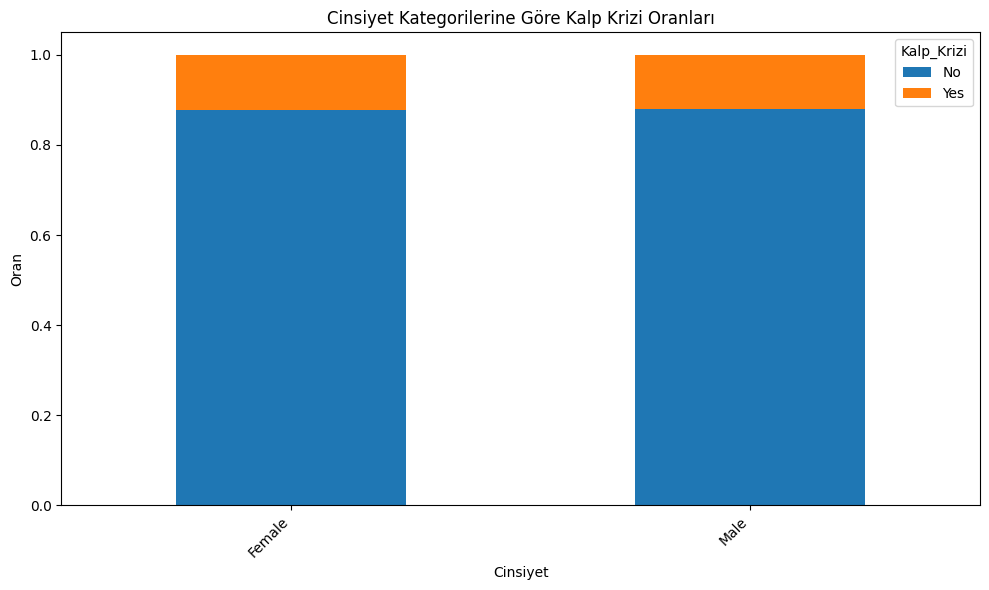


Cinsiyet vs Kalp Krizi Oranı:
Kalp_Krizi      No    Yes
Cinsiyet                 
Female      105324  14624
Male        104871  14447
------------------------------


<Figure size 1000x600 with 0 Axes>

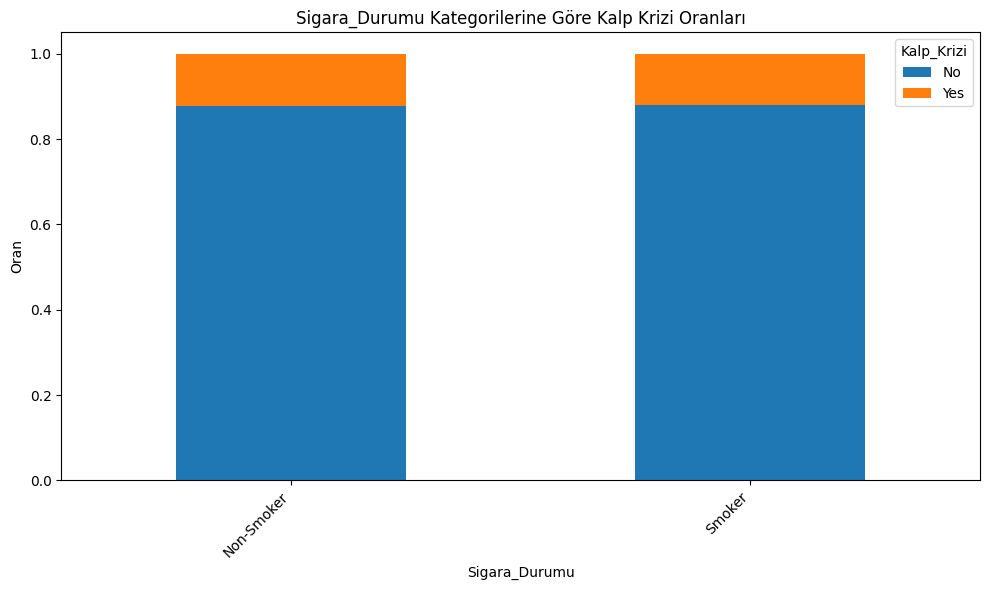


Sigara_Durumu vs Kalp Krizi Oranı:
Kalp_Krizi         No    Yes
Sigara_Durumu               
Non-Smoker     105099  14598
Smoker         105096  14473
------------------------------


<Figure size 1000x600 with 0 Axes>

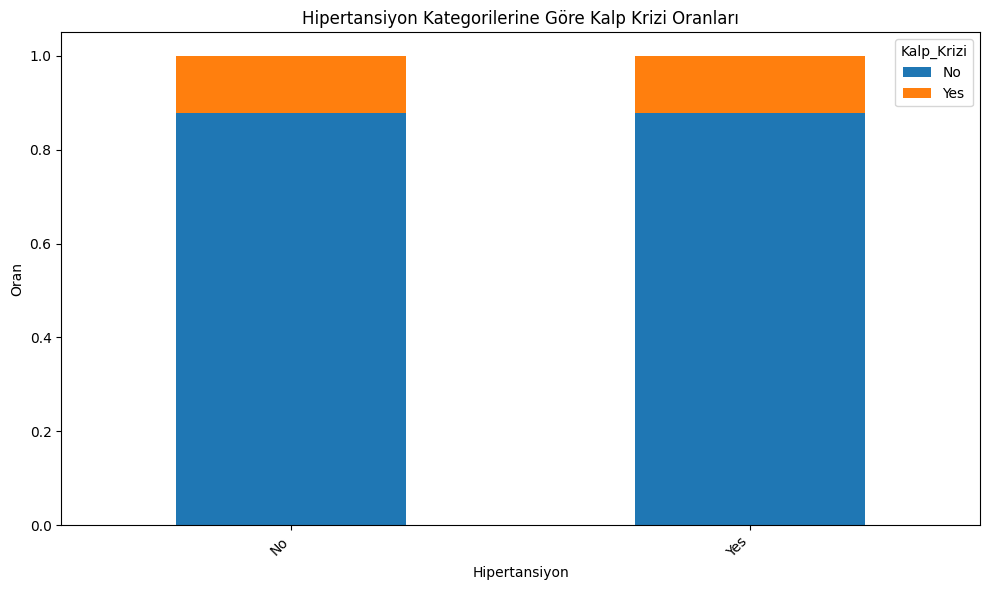


Hipertansiyon vs Kalp Krizi Oranı:
Kalp_Krizi         No    Yes
Hipertansiyon               
No             153374  21183
Yes             56821   7888
------------------------------


<Figure size 1000x600 with 0 Axes>

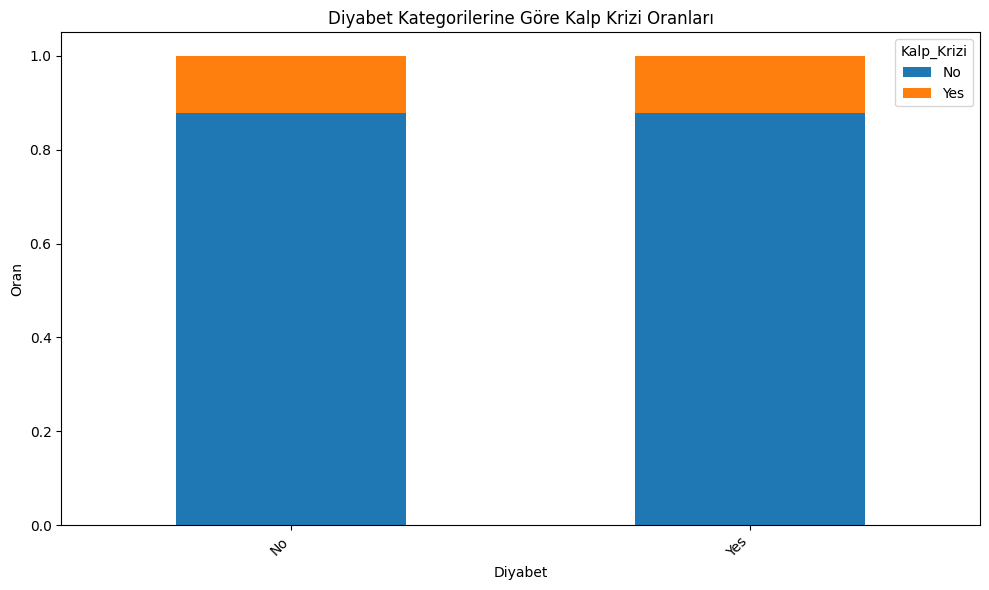


Diyabet vs Kalp Krizi Oranı:
Kalp_Krizi      No    Yes
Diyabet                  
No          186940  25854
Yes          23255   3217
------------------------------


<Figure size 1000x600 with 0 Axes>

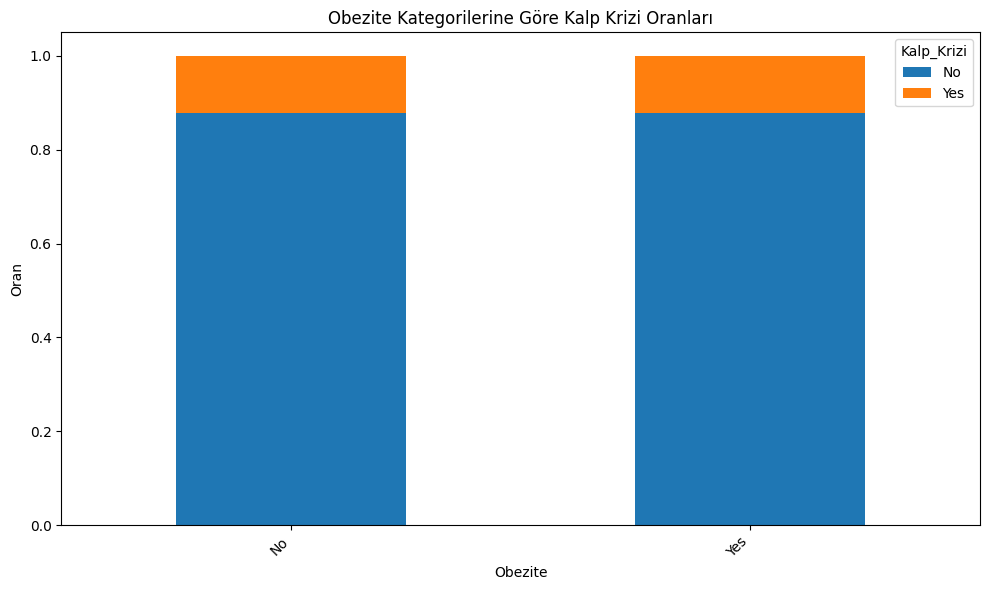


Obezite vs Kalp Krizi Oranı:
Kalp_Krizi      No    Yes
Obezite                  
No          147254  20267
Yes          62941   8804
------------------------------


<Figure size 1000x600 with 0 Axes>

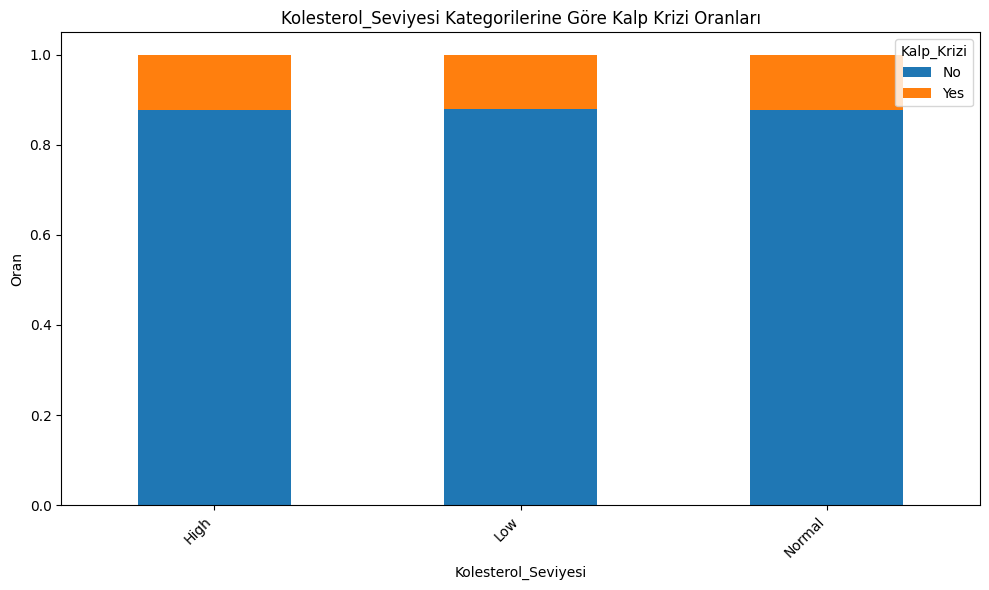


Kolesterol_Seviyesi vs Kalp Krizi Oranı:
Kalp_Krizi              No   Yes
Kolesterol_Seviyesi             
High                 69825  9795
Low                  70027  9528
Normal               70343  9748
------------------------------


<Figure size 1000x600 with 0 Axes>

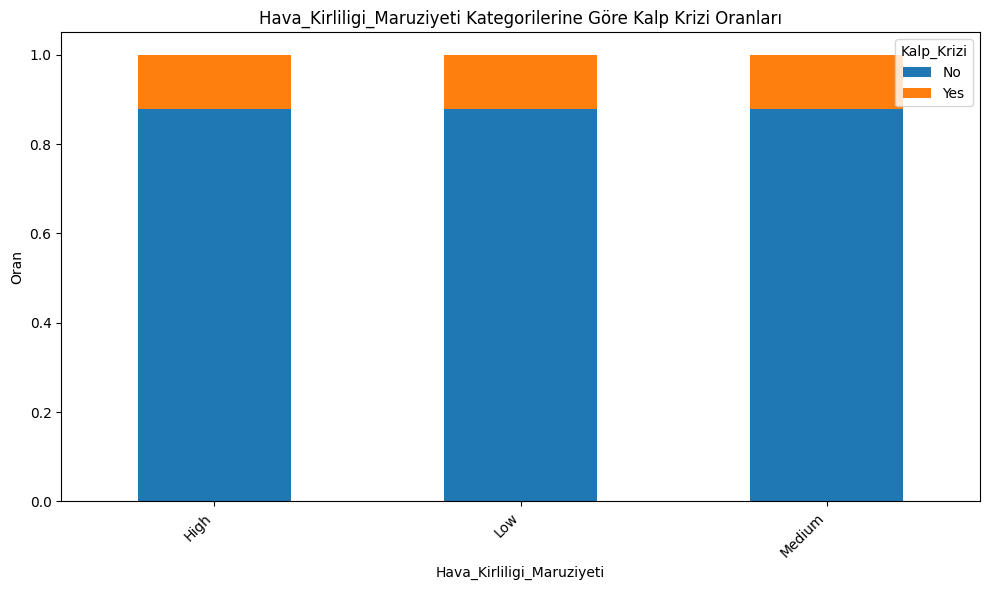


Hava_Kirliligi_Maruziyeti vs Kalp Krizi Oranı:
Kalp_Krizi                     No    Yes
Hava_Kirliligi_Maruziyeti               
High                        42190   5829
Low                         62984   8670
Medium                     105021  14572
------------------------------


<Figure size 1000x600 with 0 Axes>

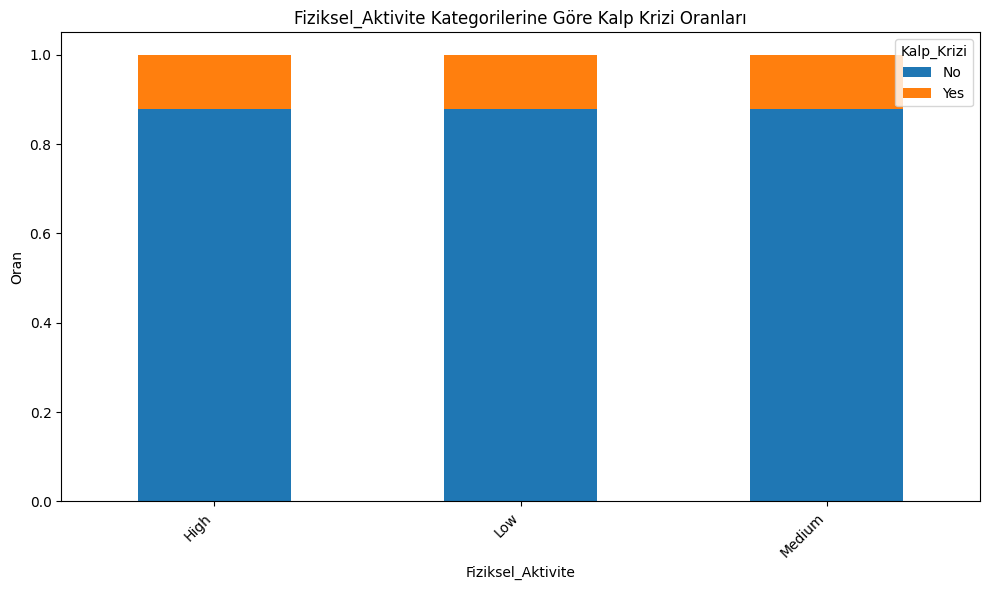


Fiziksel_Aktivite vs Kalp Krizi Oranı:
Kalp_Krizi            No   Yes
Fiziksel_Aktivite             
High               69603  9647
Low                70308  9778
Medium             70284  9646
------------------------------


<Figure size 1000x600 with 0 Axes>

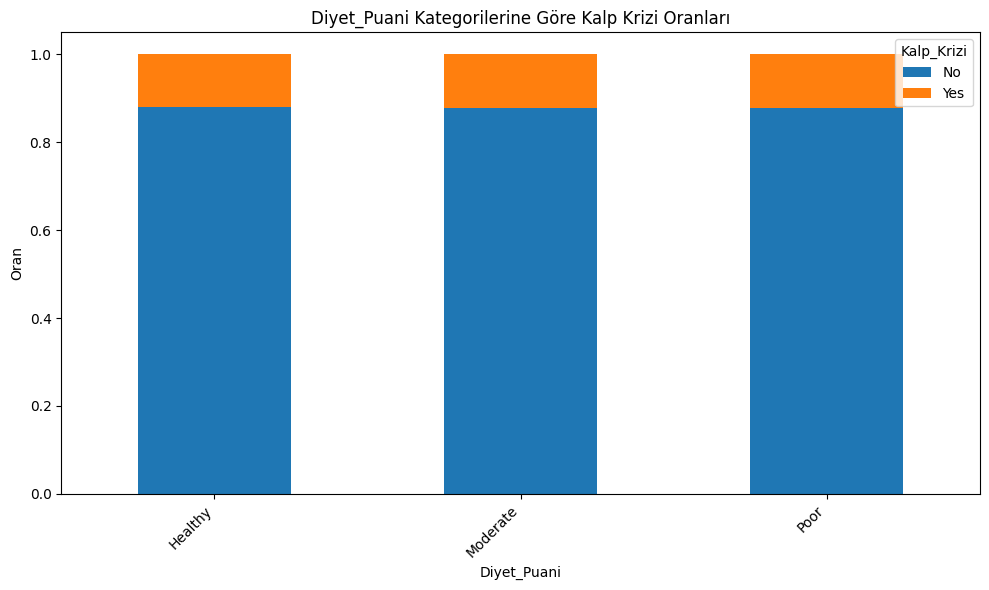


Diyet_Puani vs Kalp Krizi Oranı:
Kalp_Krizi      No   Yes
Diyet_Puani             
Healthy      70057  9599
Moderate     70225  9729
Poor         69913  9743
------------------------------


<Figure size 1000x600 with 0 Axes>

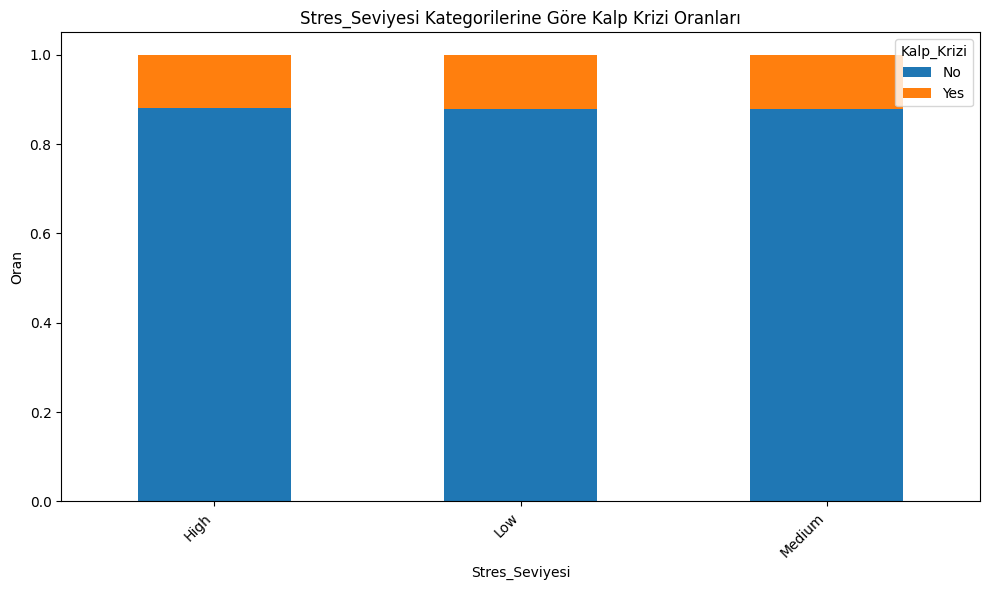


Stres_Seviyesi vs Kalp Krizi Oranı:
Kalp_Krizi         No   Yes
Stres_Seviyesi             
High            70253  9604
Low             70298  9822
Medium          69644  9645
------------------------------


<Figure size 1000x600 with 0 Axes>

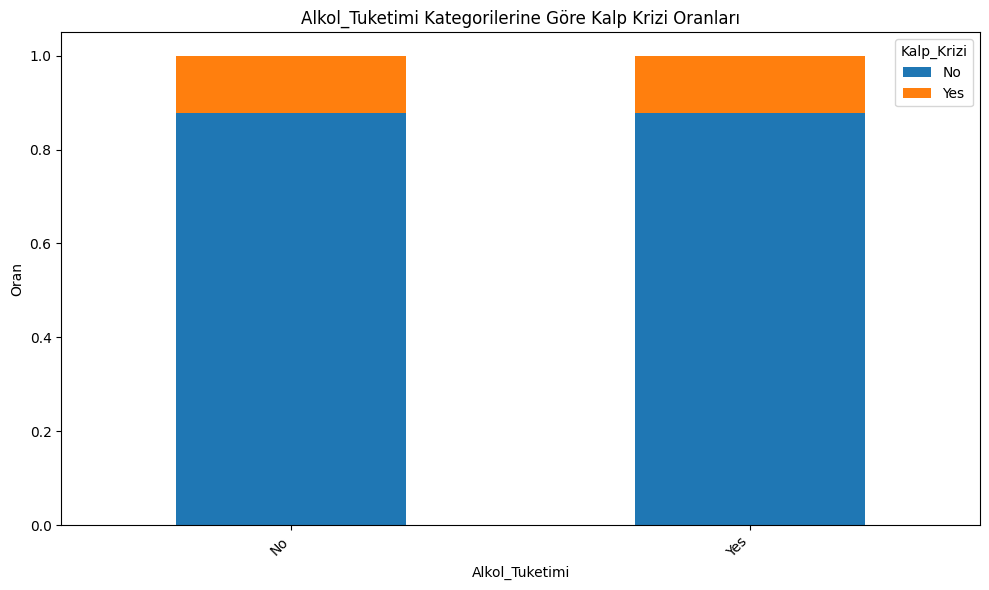


Alkol_Tuketimi vs Kalp Krizi Oranı:
Kalp_Krizi          No    Yes
Alkol_Tuketimi               
No              146864  20292
Yes              63331   8779
------------------------------


<Figure size 1000x600 with 0 Axes>

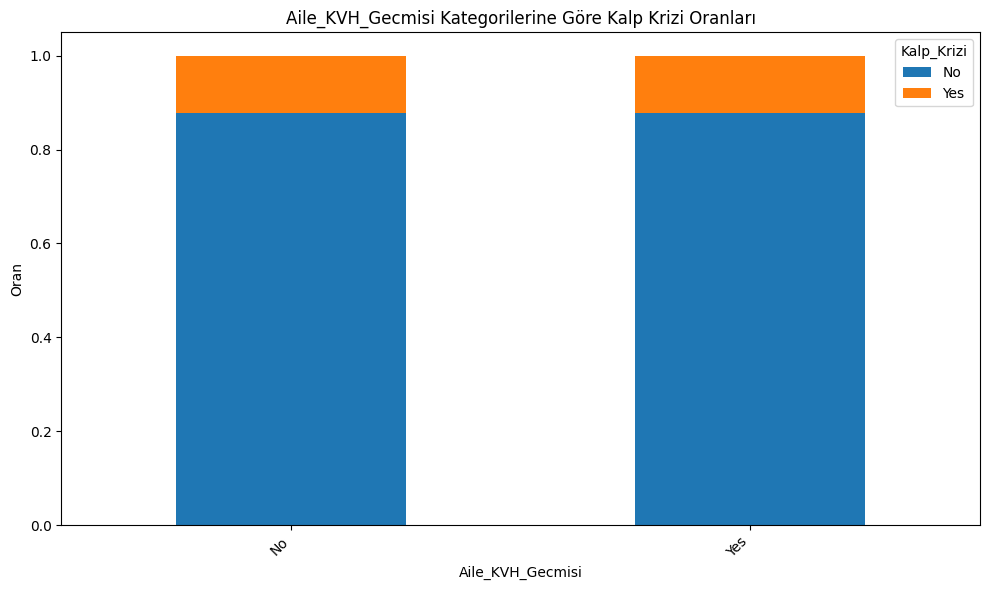


Aile_KVH_Gecmisi vs Kalp Krizi Oranı:
Kalp_Krizi            No    Yes
Aile_KVH_Gecmisi               
No                157901  21839
Yes                52294   7232
------------------------------


<Figure size 1000x600 with 0 Axes>

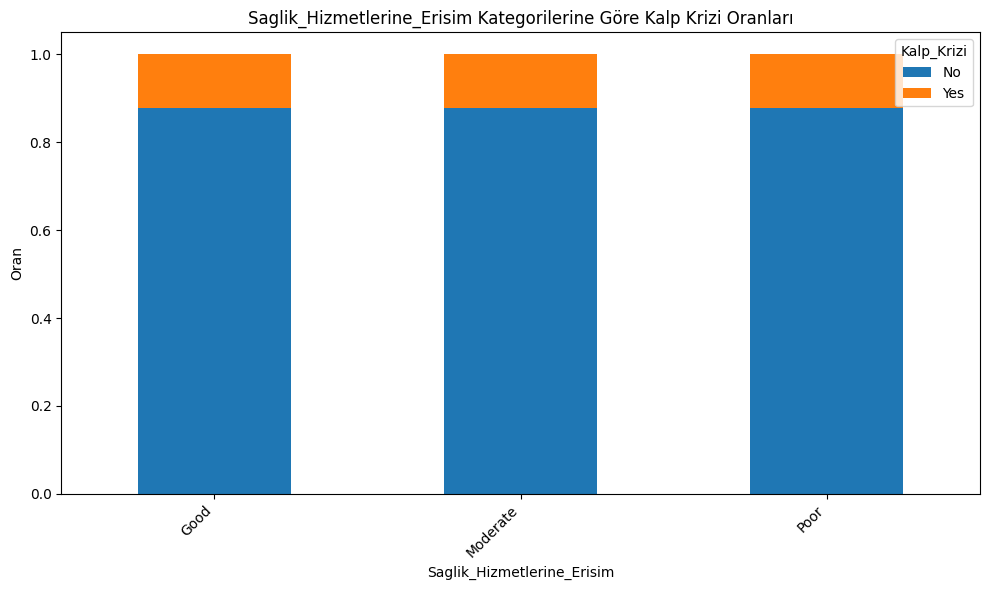


Saglik_Hizmetlerine_Erisim vs Kalp Krizi Oranı:
Kalp_Krizi                     No   Yes
Saglik_Hizmetlerine_Erisim             
Good                        69963  9680
Moderate                    70046  9665
Poor                        70186  9726
------------------------------


<Figure size 1000x600 with 0 Axes>

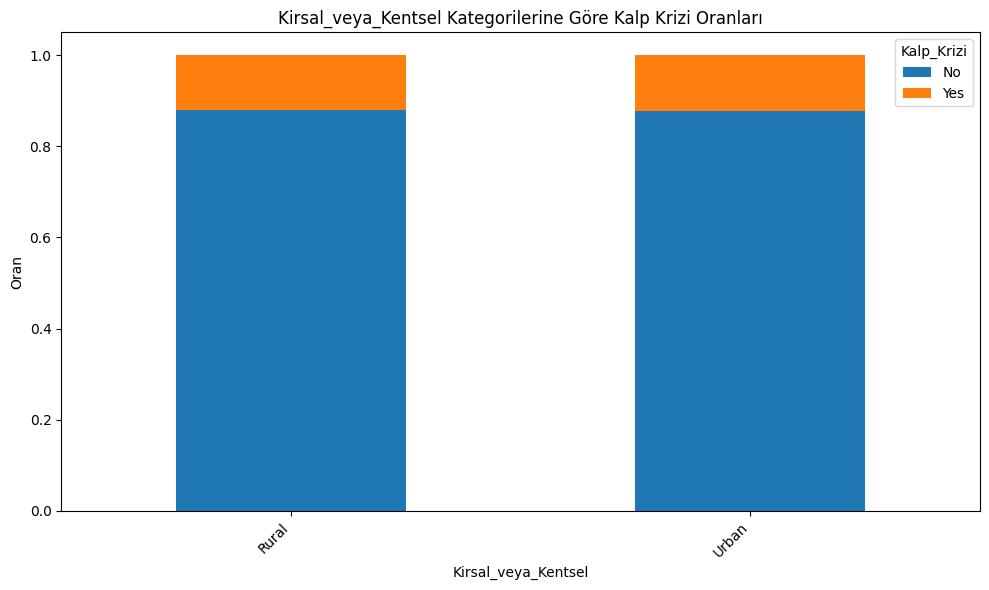


Kirsal_veya_Kentsel vs Kalp Krizi Oranı:
Kalp_Krizi               No    Yes
Kirsal_veya_Kentsel               
Rural                126148  17359
Urban                 84047  11712
------------------------------


<Figure size 1000x600 with 0 Axes>

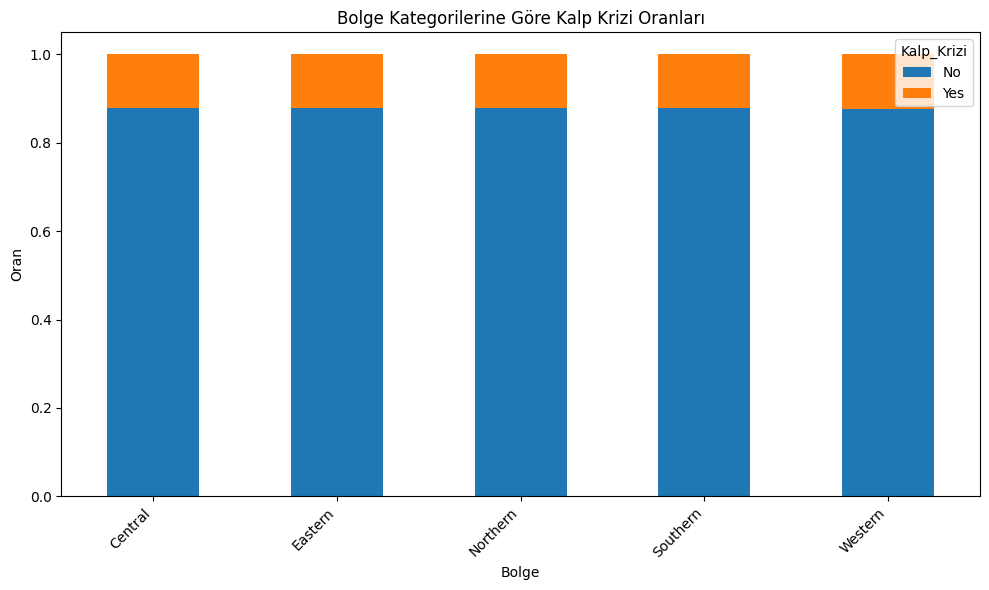


Bolge vs Kalp Krizi Oranı:
Kalp_Krizi     No   Yes
Bolge                  
Central     41949  5745
Eastern     42092  5867
Northern    41955  5732
Southern    41994  5832
Western     42205  5895
------------------------------


<Figure size 1000x600 with 0 Axes>

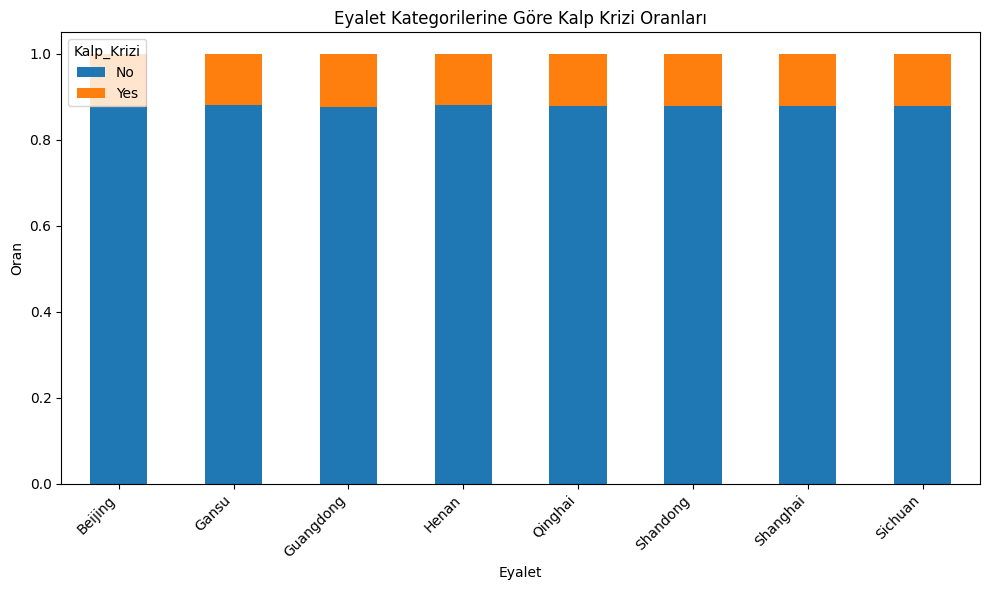


Eyalet vs Kalp Krizi Oranı:
Kalp_Krizi     No   Yes
Eyalet                 
Beijing     26356  3708
Gansu       26033  3516
Guangdong   26444  3718
Henan       26207  3560
Qinghai     26305  3612
Shandong    26367  3658
Shanghai    26278  3654
Sichuan     26205  3645
------------------------------


<Figure size 1000x600 with 0 Axes>

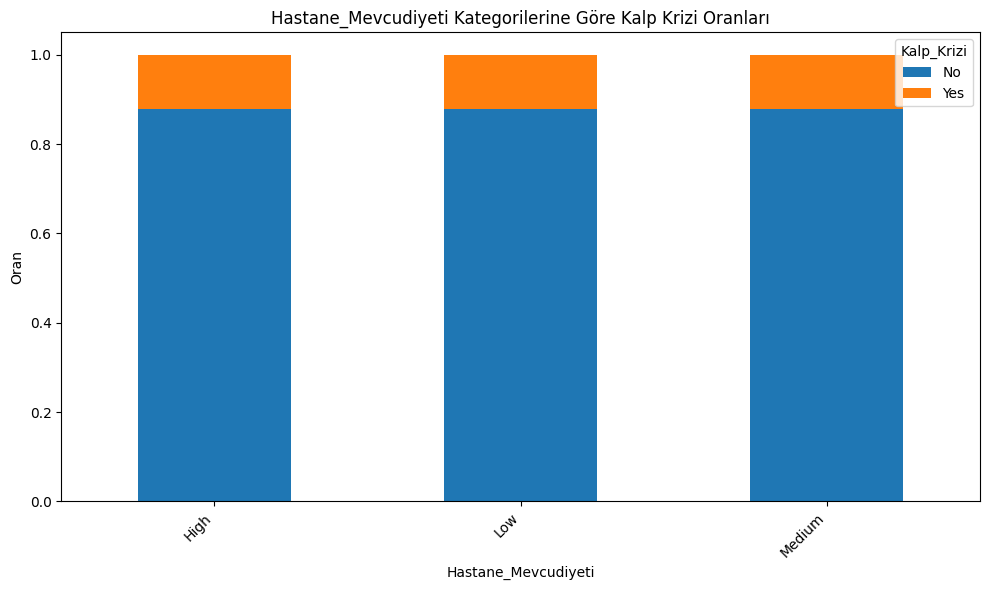


Hastane_Mevcudiyeti vs Kalp Krizi Oranı:
Kalp_Krizi              No   Yes
Hastane_Mevcudiyeti             
High                 70163  9685
Low                  69969  9620
Medium               70063  9766
------------------------------


<Figure size 1000x600 with 0 Axes>

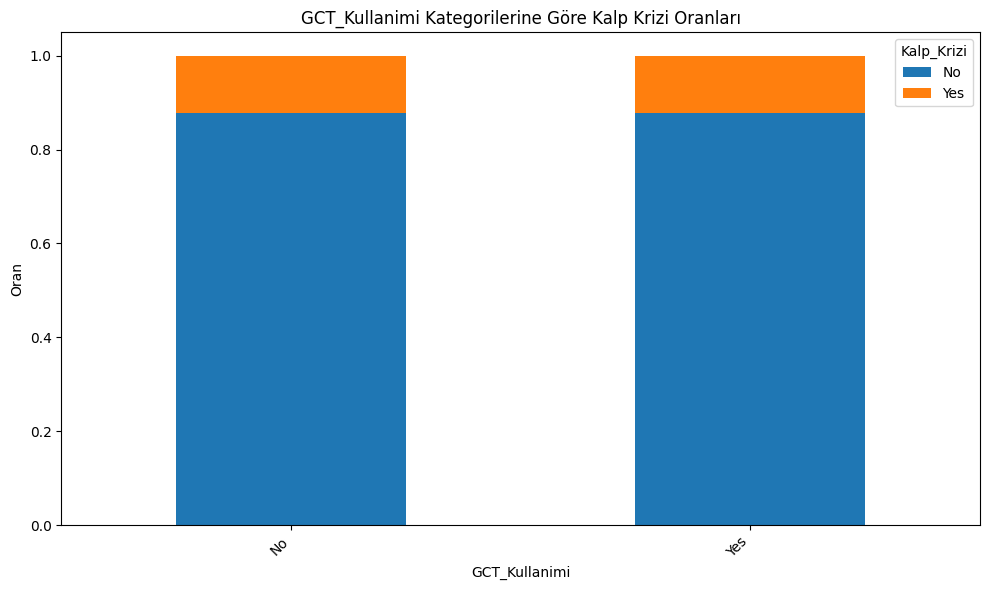


GCT_Kullanimi vs Kalp Krizi Oranı:
Kalp_Krizi         No    Yes
GCT_Kullanimi               
No             126408  17541
Yes             83787  11530
------------------------------


<Figure size 1000x600 with 0 Axes>

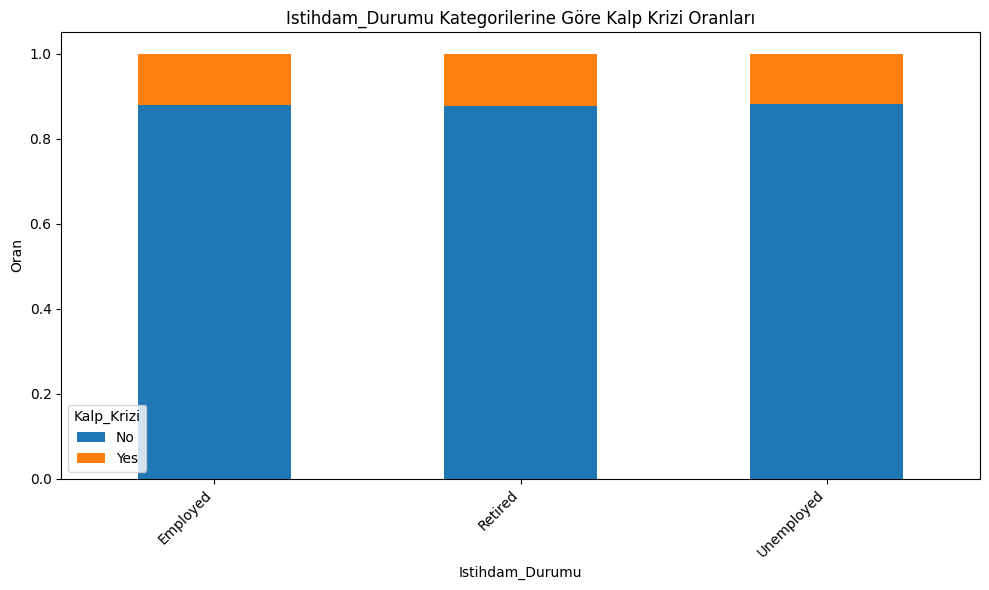


Istihdam_Durumu vs Kalp Krizi Oranı:
Kalp_Krizi          No   Yes
Istihdam_Durumu             
Employed         69989  9649
Retired          69963  9909
Unemployed       70243  9513
------------------------------


<Figure size 1000x600 with 0 Axes>

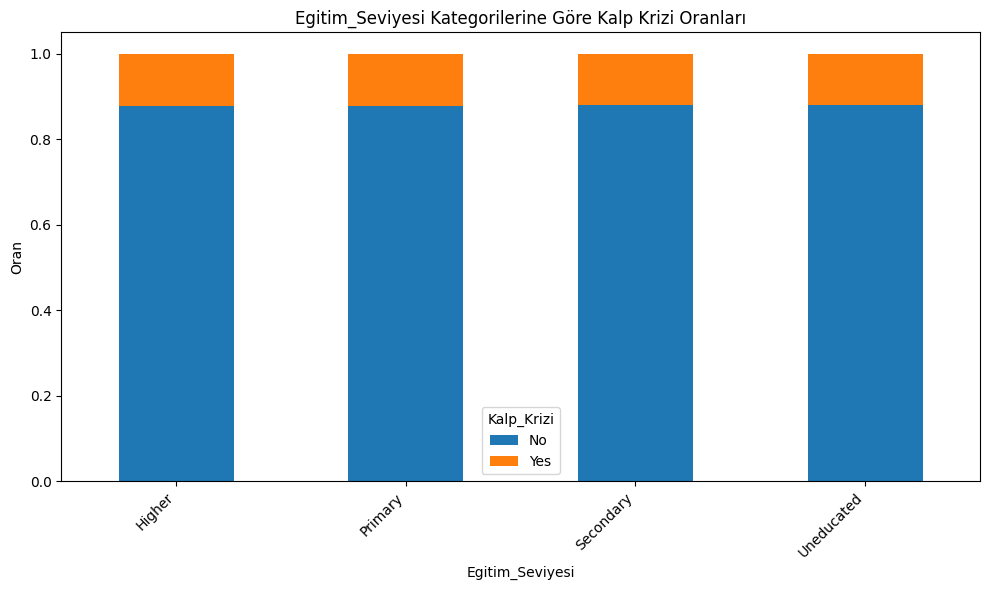


Egitim_Seviyesi vs Kalp Krizi Oranı:
Kalp_Krizi          No   Yes
Egitim_Seviyesi             
Higher           52623  7319
Primary          52581  7320
Secondary        52588  7218
Uneducated       52403  7214
------------------------------


<Figure size 1000x600 with 0 Axes>

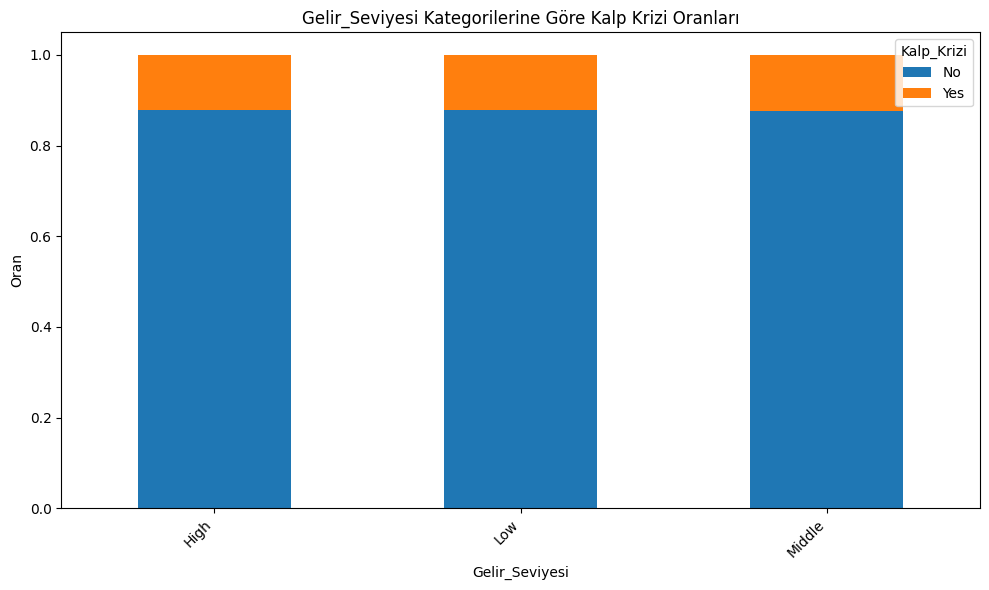


Gelir_Seviyesi vs Kalp Krizi Oranı:
Kalp_Krizi         No   Yes
Gelir_Seviyesi             
High            70471  9678
Low             70173  9624
Middle          69551  9769
------------------------------


<Figure size 1000x600 with 0 Axes>

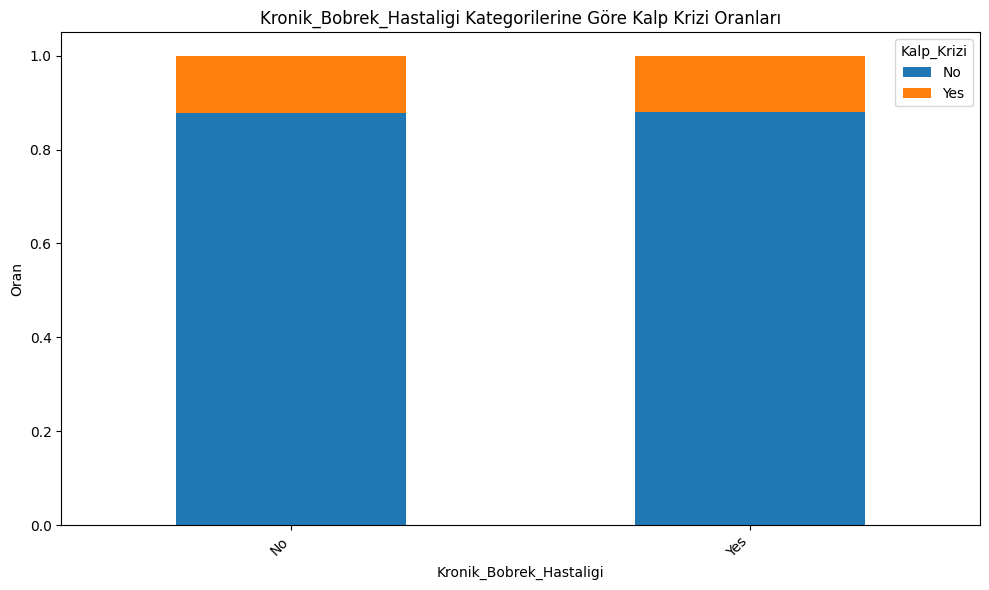


Kronik_Bobrek_Hastaligi vs Kalp Krizi Oranı:
Kalp_Krizi                   No    Yes
Kronik_Bobrek_Hastaligi               
No                       178823  24774
Yes                       31372   4297
------------------------------


<Figure size 1000x600 with 0 Axes>

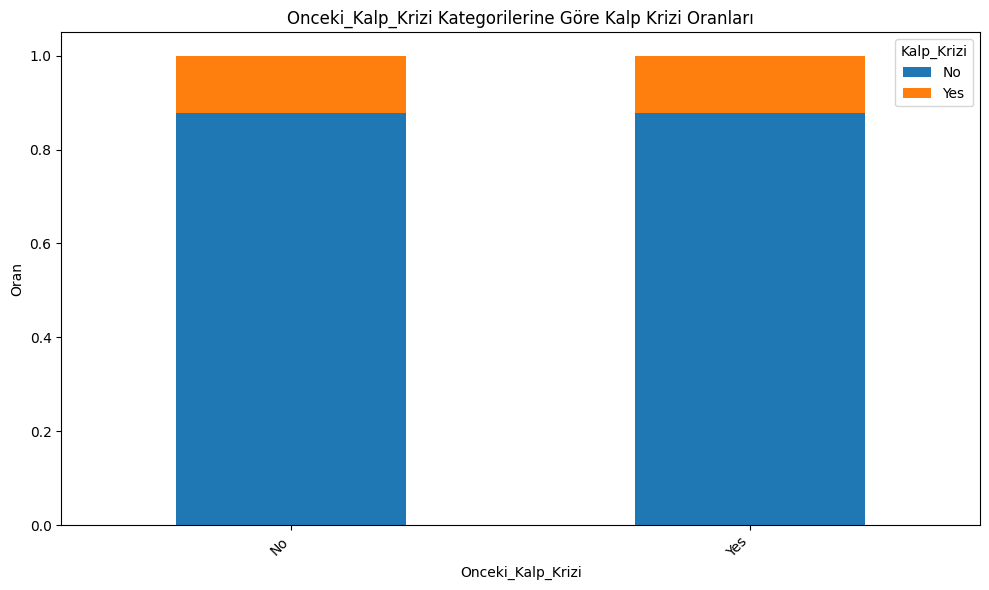


Onceki_Kalp_Krizi vs Kalp Krizi Oranı:
Kalp_Krizi             No    Yes
Onceki_Kalp_Krizi               
No                 189166  26140
Yes                 21029   2931
------------------------------


In [ ]:
# Kategorik özelliklerin kalp krizi riski ile ilişkisini incelemek istersek:
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    # Yüzdelik oranlar için crosstab kullanalım
    ct = pd.crosstab(data[col], data['Kalp_Krizi'], normalize='index') # 'index'e göre normalize et
    ct.plot(kind='bar', stacked=True, figsize=(10,6))
    plt.title(f'{col} Kategorilerine Göre Kalp Krizi Oranları')
    plt.xlabel(col)
    plt.ylabel('Oran')
    plt.legend(title='Kalp_Krizi')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Sayısal olarak değerlerini görelim:
    print(f"\n{col} vs Kalp Krizi Oranı:")
    print(pd.crosstab(data[col], data['Kalp_Krizi']))
    print("-" * 30)

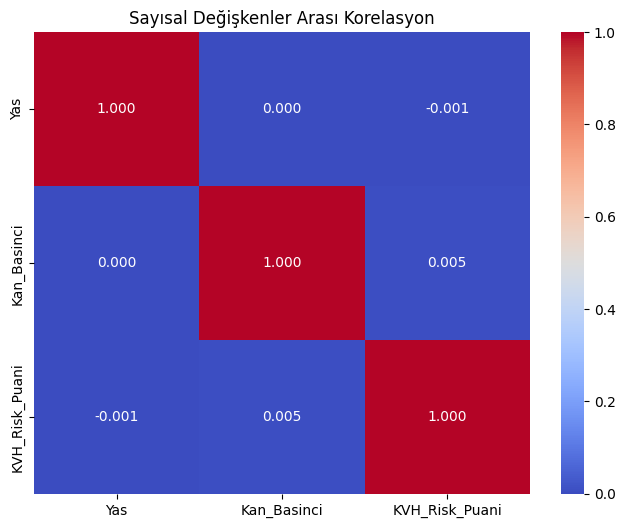


Korelasyon Matrisi:
                     Yas  Kan_Basinci  KVH_Risk_Puani
Yas             1.000000     0.000381       -0.000967
Kan_Basinci     0.000381     1.000000        0.005383
KVH_Risk_Puani -0.000967     0.005383        1.000000


In [ ]:
# Korelasyon Matrisi
plt.figure(figsize=(8, 6))
correlation_matrix = data[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Sayısal Değişkenler Arası Korelasyon')
plt.show()

print("\nKorelasyon Matrisi:")
print(correlation_matrix)

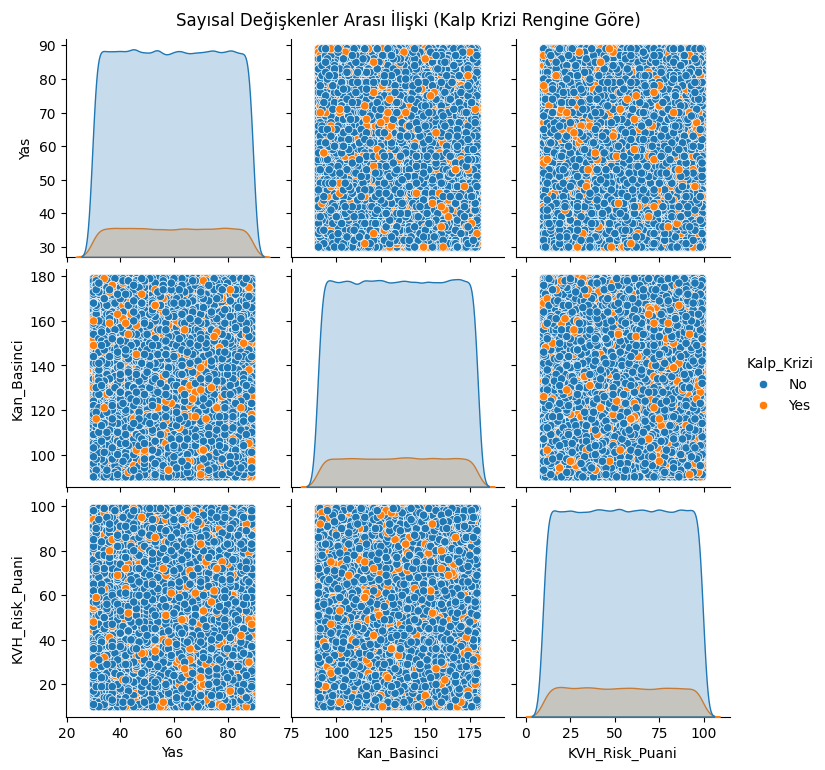

In [ ]:
# Pair Plot ile sayısal değişkenler arası ilişkiye bakalım:
sns.pairplot(data[numerical_cols + ['Kalp_Krizi']], hue='Kalp_Krizi')
plt.suptitle('Sayısal Değişkenler Arası İlişki (Kalp Krizi Rengine Göre)', y=1.02)
plt.show()

# 3 - Nitelik Dönüşümleri ve Verisetini Ayırma

In [ ]:
# Kategorik ve sayısal sütunları ayır
kategorik_sutunlar = ['Cinsiyet','Sigara_Durumu','Hipertansiyon','Diyabet','Obezite','Kolesterol_Seviyesi',
    'Hava_Kirliligi_Maruziyeti','Fiziksel_Aktivite','Diyet_Puani','Stres_Seviyesi','Alkol_Tuketimi','Aile_KVH_Gecmisi',
    'Saglik_Hizmetlerine_Erisim','Kirsal_veya_Kentsel','Bolge','Eyalet','Hastane_Mevcudiyeti','GCT_Kullanimi',
    'Istihdam_Durumu','Egitim_Seviyesi','Gelir_Seviyesi','Kronik_Bobrek_Hastaligi','Onceki_Kalp_Krizi']

sayisal_sutunlar = ['Yas', 'Kan_Basinci', 'KVH_Risk_Puani']

### Sütunlara Label Encoder Uygulanması

In [ ]:
# Kategorik özelliklere Label Encoder uygulayalım
le_features = LabelEncoder()
for sutun in kategorik_sutunlar:
    data[sutun] = le_features.fit_transform(data[sutun])

In [ ]:
# Hedef değişkene de ('Heart_Attack') Label Encoder uygulayalım
le_target = LabelEncoder()
data['Kalp_Krizi'] = le_target.fit_transform(data['Kalp_Krizi'])

### Sayısal Niteliklerin Ölçeklenmesi

In [ ]:
# Sayısal sütunlara Standard Scaler uygulayalım
scaler = StandardScaler()
data[sayisal_sutunlar] = scaler.fit_transform(data[sayisal_sutunlar])

### Hedef ve Özellik Sütunlarını Ayıralım

In [ ]:
# Hedef değişkeni ve özellikleri ayırdık
X = data.drop('Kalp_Krizi', axis=1)
y = data['Kalp_Krizi']

### Near Miss Undersampler ile Hedef Sınıf Dengesizliği Giderme

In [ ]:
# Sınıf dengesizliğini kontrol ettik
print("Sınıf dağılımı (önce):")
print(y.value_counts())


# NearMiss Version 2 ile hedeh sınıfı dengesizliğini giderelim
nm = NearMiss(version=2, n_jobs=-1)
X_resampled, y_resampled = nm.fit_resample(X, y)

Sınıf dağılımı (önce):
Kalp_Krizi
0    210195
1     29071
Name: count, dtype: int64


In [ ]:
# Dengeleme sonrası kontrol edelim
print("\nSınıf dağılımı (sonra):")
print(pd.Series(y_resampled).value_counts())


Sınıf dağılımı (sonra):
Kalp_Krizi
0    29071
1    29071
Name: count, dtype: int64


# 4 - Modellerin Eğitilmesi

In [ ]:
# Makine öğrenmesi modellerini tanımladık
models = {
    'Logistic Regression': LogisticRegression(random_state=12, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=12),
    'Random Forest': RandomForestClassifier(random_state=12, n_estimators=100, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=12, n_estimators=100),
    'AdaBoost': AdaBoostClassifier(random_state=12, n_estimators=100),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Neural Network (MLP)': MLPClassifier(random_state=12, max_iter=1000, early_stopping=True),
    'XGBoost': XGBClassifier(random_state=12, eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=12, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostClassifier(random_state=12, verbose=False)
}

# Sonuçları saklamak için sözlük oluşturalım
results = {}
confusion_matrices = {}

### Çapraz Doğrulama ile Model Eğitimi

In [ ]:
# Çapraz doğrulama için StratifiedKFold tanımladık
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

print("\n\nMakine Öğrenmesi Modelleri 5-Katlı Çapraz Doğrulama ile Değerlendiriliyor...")
# Her model için eğitim ve değerlendirme yapıyoruz
for name, model in models.items():
    print(f"{name} değerlendiriliyor...")

    # Metrikleri tanımla
    scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    # cross_validate ile model performansını birden çok metrikle ölç
    cv_results = cross_validate(
        estimator=model,
        X=X_resampled,
        y=y_resampled,
        cv=cv_strategy,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    # Metriklerin ortalamasını al ve sonuçlara kaydet
    results[name] = {
        'Accuracy': cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'F1-Score': cv_results['test_f1'].mean(),
        'ROC-AUC': cv_results['test_roc_auc'].mean()
    }

    # Confusion matrix için çapraz doğrulama tahminleri al
    y_pred = cross_val_predict(
        estimator=model,
        X=X_resampled,
        y=y_resampled,
        cv=cv_strategy,
        n_jobs=-1
    )

    # Confusion matrix sakla
    confusion_matrices[name] = confusion_matrix(y_resampled, y_pred)



Makine Öğrenmesi Modelleri 5-Katlı Çapraz Doğrulama ile Değerlendiriliyor...
Logistic Regression değerlendiriliyor...
Decision Tree değerlendiriliyor...
Random Forest değerlendiriliyor...
Gradient Boosting değerlendiriliyor...
AdaBoost değerlendiriliyor...
KNN değerlendiriliyor...
Naive Bayes değerlendiriliyor...
Neural Network (MLP) değerlendiriliyor...
XGBoost değerlendiriliyor...
LightGBM değerlendiriliyor...
CatBoost değerlendiriliyor...


# 5 - Derin Öğrenme Model Eğitimi

### Çapraz Doğrulama için Derin Öğrenme Modelinin Tanımlanması

In [ ]:
# --- DERİN ÖĞRENME MODELİ İÇİN MANUEL ÇAPRAZ DOĞRULAMA ---
print("\n\nDerin Öğrenme Modeli 5-Katlı Çapraz Doğrulama ile Değerlendiriliyor...")

# Her katlamada (fold) yeniden oluşturulabilmesi için model oluşturma fonksiyonu tanımladık
def create_dl_model(input_shape):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model




Derin Öğrenme Modeli 5-Katlı Çapraz Doğrulama ile Değerlendiriliyor...


In [ ]:
# Early stopping in tanımlanması
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
)

In [ ]:
# Metrikleri ve tahminleri saklamak için listeler tanımladık
dl_scores = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': [], 'ROC-AUC': []}
all_y_true = []
all_y_pred_dl = []

In [ ]:
# X ve y'yi numpy array'e çevirerek daha hızlı indeksleme sağlayabiliriz
X_np = X_resampled.to_numpy()
y_np = y_resampled.to_numpy()

In [ ]:
for fold, (train_index, val_index) in enumerate(cv_strategy.split(X_np, y_np)):
    print(f"Derin Öğrenme - Fold {fold+1}/5")
    X_train, X_val = X_np[train_index], X_np[val_index]
    y_train, y_val = y_np[train_index], y_np[val_index]

    # Her fold için modeli yeniden oluştur (ağırlıkların sızmasını önle)
    dl_model = create_dl_model(X_train.shape[1])

    # Modeli eğit
    dl_model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val), # Katmanın validasyon setini kullan
        callbacks=[early_stopping],
        verbose=0
    )

    # Tahminler
    y_pred_proba_dl = dl_model.predict(X_val).flatten()
    y_pred_dl = (y_pred_proba_dl > 0.5).astype(int)

    # Metrikleri hesapla ve listelere ekle
    dl_scores['Accuracy'].append(accuracy_score(y_val, y_pred_dl))
    dl_scores['Precision'].append(precision_score(y_val, y_pred_dl, zero_division=0))
    dl_scores['Recall'].append(recall_score(y_val, y_pred_dl, zero_division=0))
    dl_scores['F1-Score'].append(f1_score(y_val, y_pred_dl, zero_division=0))
    dl_scores['ROC-AUC'].append(roc_auc_score(y_val, y_pred_proba_dl))

    # Confusion matrix için tüm tahminleri ve gerçek değerleri topla
    all_y_true.extend(y_val)
    all_y_pred_dl.extend(y_pred_dl)

Derin Öğrenme - Fold 1/5
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step
Derin Öğrenme - Fold 2/5
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
Derin Öğrenme - Fold 3/5
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step
Derin Öğrenme - Fold 4/5
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step
Derin Öğrenme - Fold 5/5
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step


In [ ]:
# Ortalama metrikleri hesapla
dl_results = {metric: np.mean(values) for metric, values in dl_scores.items()}

# Derin öğrenme sonuçlarını ekle
results['Deep Learning'] = dl_results
confusion_matrices['Deep Learning'] = confusion_matrix(all_y_true, all_y_pred_dl)

print(f"\nDerin Öğrenme Ortalama Performansı:")
for metric, value in dl_results.items():
    print(f"{metric}: {value:.4f}")


Derin Öğrenme Ortalama Performansı:
Accuracy: 0.8780
Precision: 0.9678
Recall: 0.7822
F1-Score: 0.8650
ROC-AUC: 0.9178


### DL ve ML Modelleri Değerlendirme

In [ ]:
# Tüm sonuçları DataFrame olarak göster (DL dahil)
results_df_all = pd.DataFrame(results).T
print("\n\nTÜM MODELLERİN 5-KATLI ÇAPRAZ DOĞRULAMA PERFORMANS KARŞILAŞTIRMASI:")
print("="*80)
print(results_df_all.sort_values(by='F1-Score', ascending=False).round(4))
print("="*80)



TÜM MODELLERİN 5-KATLI ÇAPRAZ DOĞRULAMA PERFORMANS KARŞILAŞTIRMASI:
                      Accuracy  Precision  Recall  F1-Score  ROC-AUC
CatBoost                0.9013     0.9783  0.8208    0.8926   0.9258
XGBoost                 0.8925     0.9568  0.8222    0.8844   0.9226
LightGBM                0.8924     0.9682  0.8115    0.8829   0.9234
Neural Network (MLP)    0.8838     0.9495  0.8108    0.8747   0.9210
Gradient Boosting       0.8832     0.9582  0.8014    0.8728   0.9190
Random Forest           0.8822     0.9604  0.7973    0.8713   0.9181
Deep Learning           0.8780     0.9678  0.7822    0.8650   0.9178
AdaBoost                0.8500     0.9212  0.7665    0.8363   0.9040
Naive Bayes             0.8435     0.8811  0.7940    0.8353   0.9094
Decision Tree           0.7998     0.7936  0.8103    0.8019   0.7998
KNN                     0.7879     0.9255  0.6261    0.7469   0.8427
Logistic Regression     0.5180     0.5191  0.4916    0.5050   0.5248


# 6 - Sonuçlar ve Görsel Grafikler

### Karar Matrisi ile Tüm Modellerin Karşılaştırılması

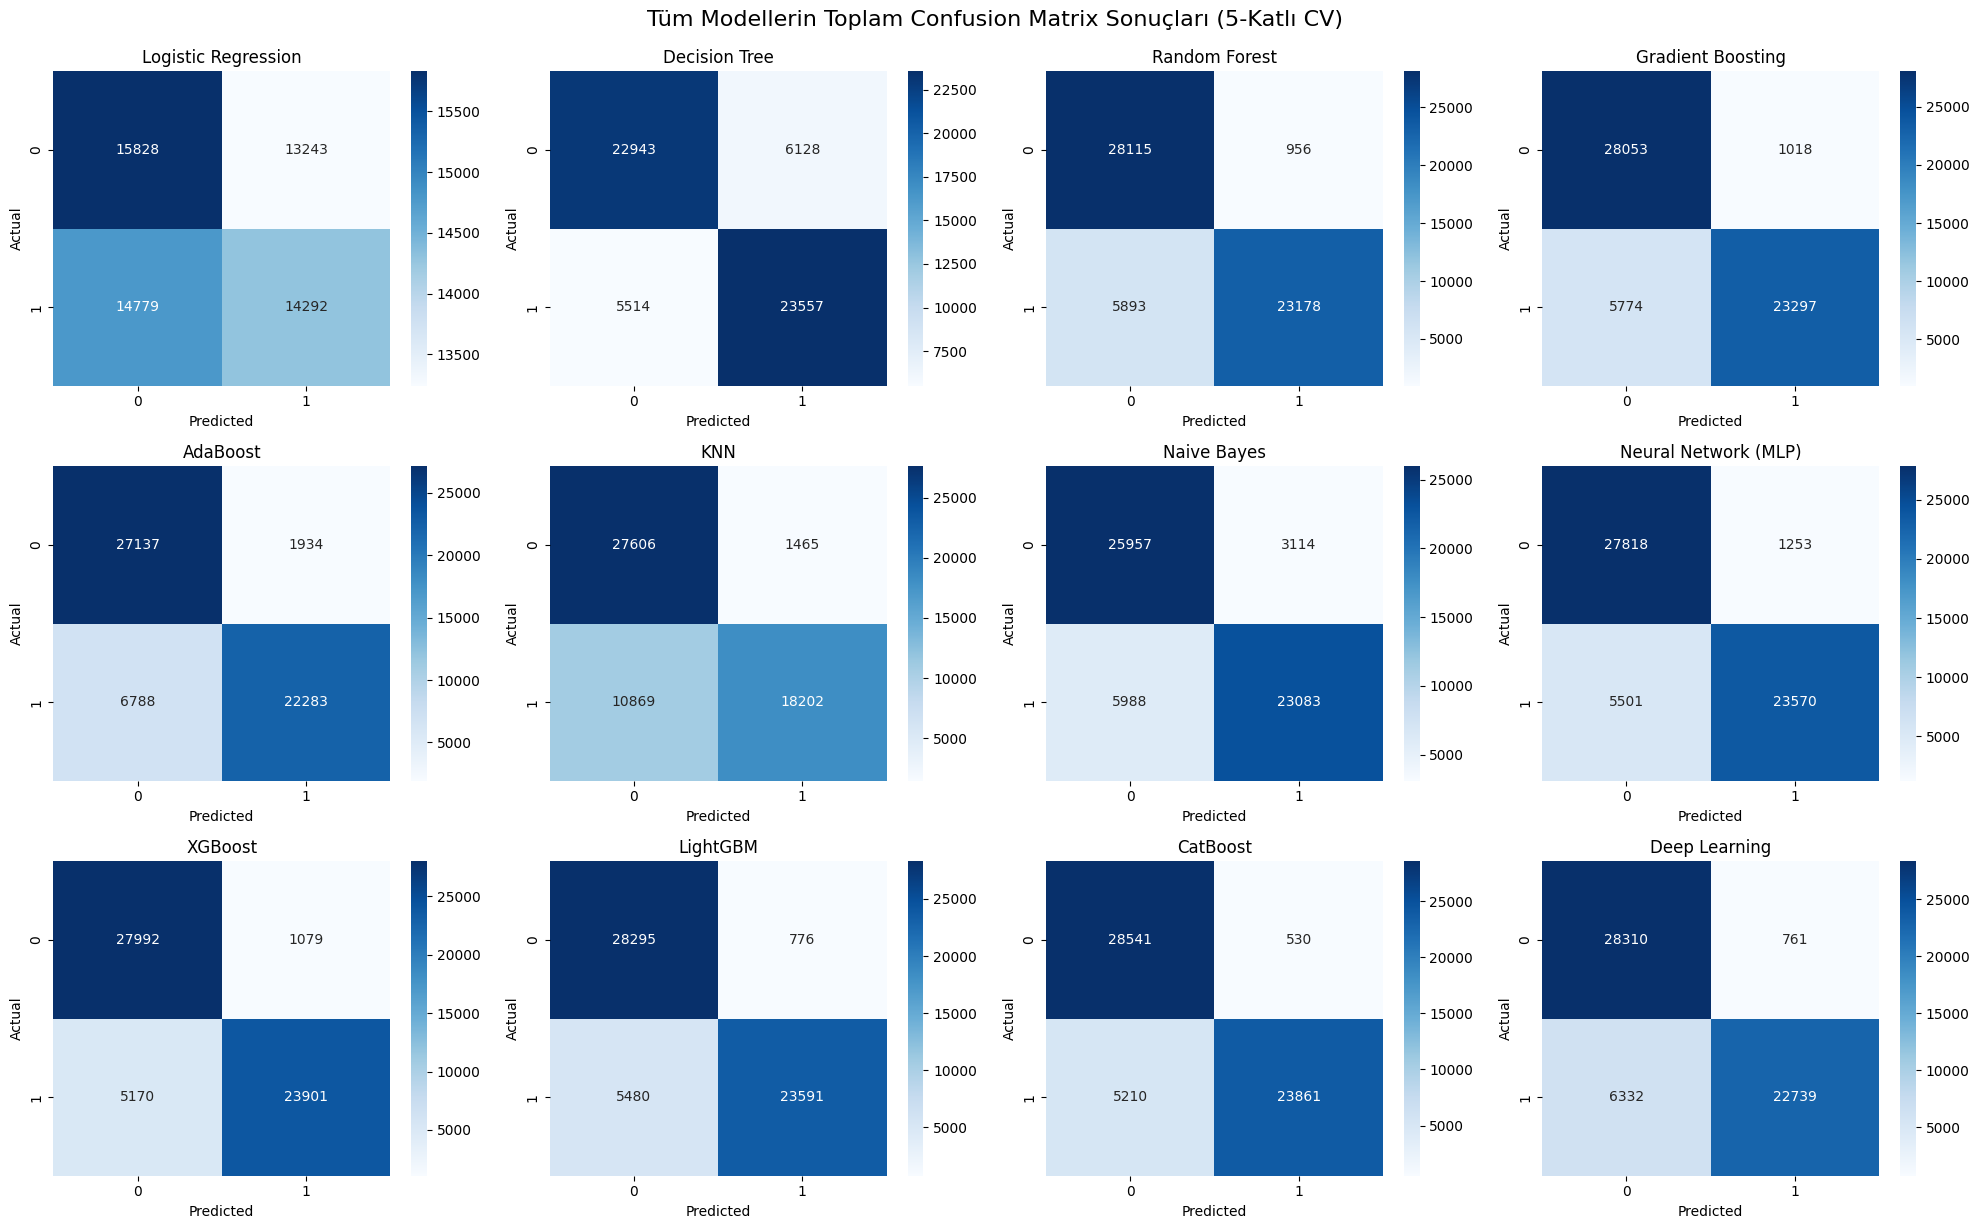

In [ ]:
# Model sayısına göre subplot düzenini ayarla
num_total_models_for_cm = len(confusion_matrices)
cols_cm = 4
rows_cm = (num_total_models_for_cm + cols_cm -1) // cols_cm

if num_total_models_for_cm > 0:
    fig_cm, axes_cm = plt.subplots(rows_cm, cols_cm, figsize=(5*cols_cm, 4*rows_cm))
    axes_cm = axes_cm.ravel()

    for idx, (name, cm) in enumerate(confusion_matrices.items()):
        if idx < len(axes_cm):
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[idx])
            axes_cm[idx].set_title(f'{name}')
            axes_cm[idx].set_xlabel('Predicted')
            axes_cm[idx].set_ylabel('Actual')

    for i in range(num_total_models_for_cm, len(axes_cm)):
        fig_cm.delaxes(axes_cm[i])

    plt.tight_layout()
    plt.suptitle('Tüm Modellerin Toplam Confusion Matrix Sonuçları (5-Katlı CV)', fontsize=16, y=1.02 if rows_cm > 1 else 1.05)
    plt.show()

### Tüm Modellerin Performans Karşılaştırma Grafiği

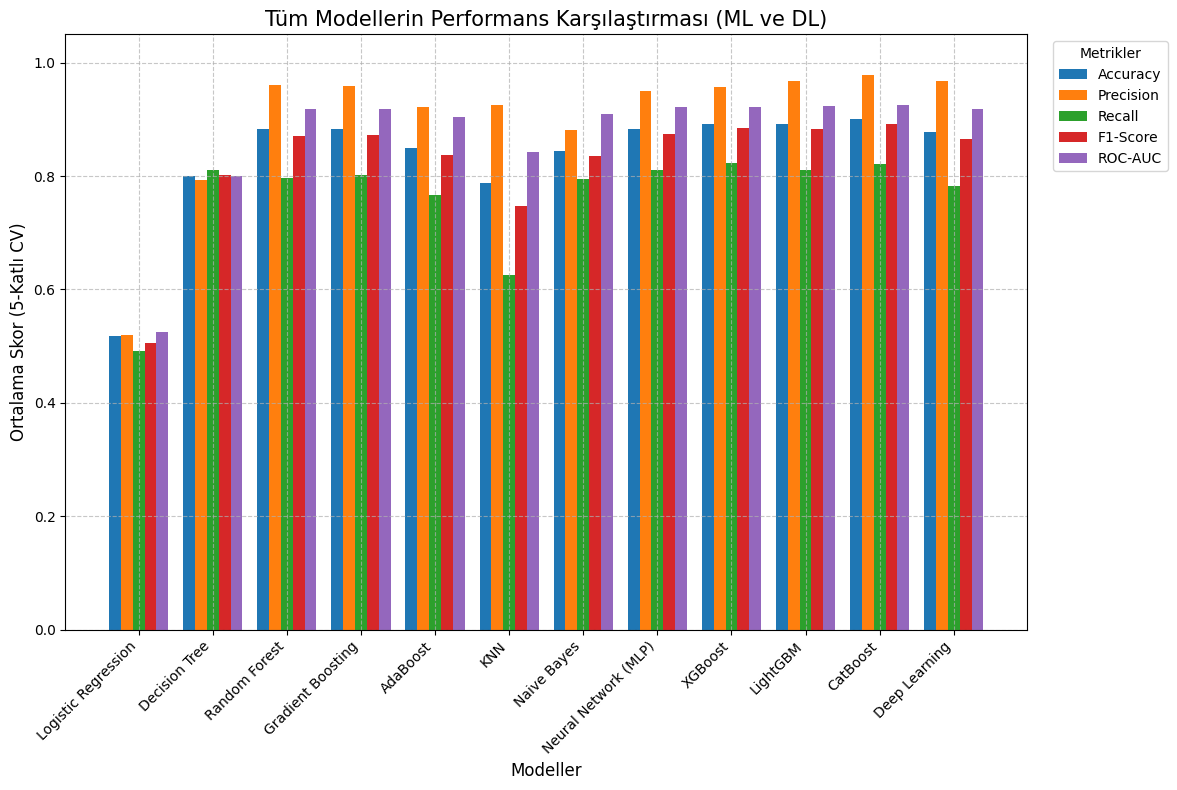

In [ ]:
# Tüm Modellerin (ML + DL) Performans karşılaştırma grafiği
if not results_df_all.empty:
    fig_perf, ax_perf = plt.subplots(figsize=(14, 8))
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    num_metrics = len(metrics_to_plot)
    num_total_models_for_perf_chart = len(results_df_all)

    total_bar_width_factor = 0.8
    bar_width = total_bar_width_factor / num_metrics # Bar genişliğini metrik sayısına göre ayarla

    x_indices = np.arange(len(results_df_all))

    for i, metric in enumerate(metrics_to_plot):
        values = results_df_all[metric]
        bar_positions = x_indices - (total_bar_width_factor / 2) + (i * bar_width) + (bar_width / 2)
        ax_perf.bar(bar_positions, values, bar_width, label=metric)

    ax_perf.set_xlabel('Modeller', fontsize=12)
    ax_perf.set_ylabel('Ortalama Skor (5-Katlı CV)', fontsize=12)
    ax_perf.set_title('Tüm Modellerin Performans Karşılaştırması (ML ve DL)', fontsize=15)
    ax_perf.set_xticks(x_indices)
    ax_perf.set_xticklabels(results_df_all.index, rotation=45, ha="right")
    ax_perf.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Metrikler")
    ax_perf.grid(True, linestyle='--', alpha=0.7)
    ax_perf.set_ylim(0, 1.05)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()